## Business Question 16: Which Customer Segment Is Most Valuable to the Bank?

### Objective
To identify the most valuable customer segment by analyzing
customer income, account balances, deposits, and loan amounts.

### Business Purpose
This analysis helps the bank understand the contribution of
different customer segments and identify potential target groups
for future banking products.

### Step 1: Customer Segmentation

Customers are categorized into four income groups:
- Low Income
- Lower-Middle Income
- Upper-Middle Income
- High Income

These groups will be used to compare customer deposits and loans.

In [1]:
import pandas as pd
import numpy as np

customers = pd.read_csv("../data/raw_dataset/customers.csv")
accounts = pd.read_csv("../data/raw_dataset/accounts.csv")
transactions = pd.read_csv("../data/raw_dataset/transactions.csv")
loans = pd.read_csv("../data/raw_dataset/loans.csv")
branches = pd.read_csv("../data/raw_dataset/branches.csv")

print("All datasets loaded successfully.")


income_bins = [0, 25000, 50000, 100000, np.inf]

income_labels = [
    "Low Income",
    "Lower-Middle Income",
    "Upper-Middle Income",
    "High Income"
]


customers["IncomeSegment"] = pd.cut(
    customers["Income"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

All datasets loaded successfully.


### Step 2: Calculate Customer-Level Metrics

Calculate the total account balance and total loan amount
for each customer.

These metrics will help compare the financial contribution
of each income segment.

In [2]:
customer_deposits = (
    accounts.groupby("CustomerID", as_index=False)
    .agg(
        TotalDeposits=("Balance", "sum")
    )
)

customer_loans = (
    loans.groupby("CustomerID", as_index=False)
    .agg(
        TotalLoans=("LoanAmount", "sum"),
        LoanCount=("LoanID", "count")
    )
)

customer_value = (
    customers[
        ["CustomerID", "Income", "IncomeSegment"]
    ]
    .merge(
        customer_deposits,
        on="CustomerID",
        how="left"
    )
    .merge(
        customer_loans,
        on="CustomerID",
        how="left"
    )
)

customer_value[
    ["TotalDeposits", "TotalLoans", "LoanCount"]
] = customer_value[
    ["TotalDeposits", "TotalLoans", "LoanCount"]
].fillna(0)

### Step 3: Analyze Customer Segments

Group customers by income segment and calculate:
- Total Customers
- Average Income
- Total Deposits
- Average Deposit
- Total Loans
- Average Loan Amount

Compare these metrics to understand the financial
contribution of each customer segment.

In [3]:
segment_analysis = (
    customer_value
    .groupby("IncomeSegment", observed=False)
    .agg(
        TotalCustomers=("CustomerID", "nunique"),
        AverageIncome=("Income", "mean"),
        TotalDeposits=("TotalDeposits", "sum"),
        AverageDeposit=("TotalDeposits", "mean"),
        TotalLoans=("TotalLoans", "sum"),
        AverageLoan=("TotalLoans", "mean")
    )
    .reset_index()
)

segment_analysis["DepositShare(%)"] = (
    segment_analysis["TotalDeposits"]
    / segment_analysis["TotalDeposits"].sum()
    * 100
)

segment_analysis["LoanShare(%)"] = (
    segment_analysis["TotalLoans"]
    / segment_analysis["TotalLoans"].sum()
    * 100
)

segment_analysis

,IncomeSegment,TotalCustomers,AverageIncome,TotalDeposits,AverageDeposit,TotalLoans,AverageLoan,DepositShare(%),LoanShare(%)
0,Low Income,142322,19472.810064,2.285766e+10,160285.393614,7.398551e+10,518810.658361,14.210747,14.092970
1,Lower-Middle Income,432872,37132.669845,6.965379e+10,160588.444320,2.282322e+11,526194.738552,43.304192,43.474322
2,Upper-Middle Income,351071,68096.922366,5.663935e+10,161022.057733,1.843880e+11,524203.421570,35.213031,35.122754
3,High Income,72735,131098.568741,1.169689e+10,160442.385496,3.837592e+10,526389.764484,7.272030,7.309954


### Step 4: Identify the Segment with the Highest Deposits

Sort customer segments by total deposits to identify
which segment contributes the largest deposit amount.

In [4]:
segment_analysis = segment_analysis.sort_values(
    by="TotalDeposits",
    ascending=False
)

segment_analysis

,IncomeSegment,TotalCustomers,AverageIncome,TotalDeposits,AverageDeposit,TotalLoans,AverageLoan,DepositShare(%),LoanShare(%)
1,Lower-Middle Income,432872,37132.669845,6.965379e+10,160588.444320,2.282322e+11,526194.738552,43.304192,43.474322
2,Upper-Middle Income,351071,68096.922366,5.663935e+10,161022.057733,1.843880e+11,524203.421570,35.213031,35.122754
0,Low Income,142322,19472.810064,2.285766e+10,160285.393614,7.398551e+10,518810.658361,14.210747,14.092970
3,High Income,72735,131098.568741,1.169689e+10,160442.385496,3.837592e+10,526389.764484,7.272030,7.309954


## BQ16: Customer Segment Value Analysis

This visualization compares customer segments based on their
customer count, total deposits, and total loan amount.

The analysis helps identify how customer segments contribute
to the bank's current portfolio.

Note: Portfolio contribution does not represent overall
customer profitability.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

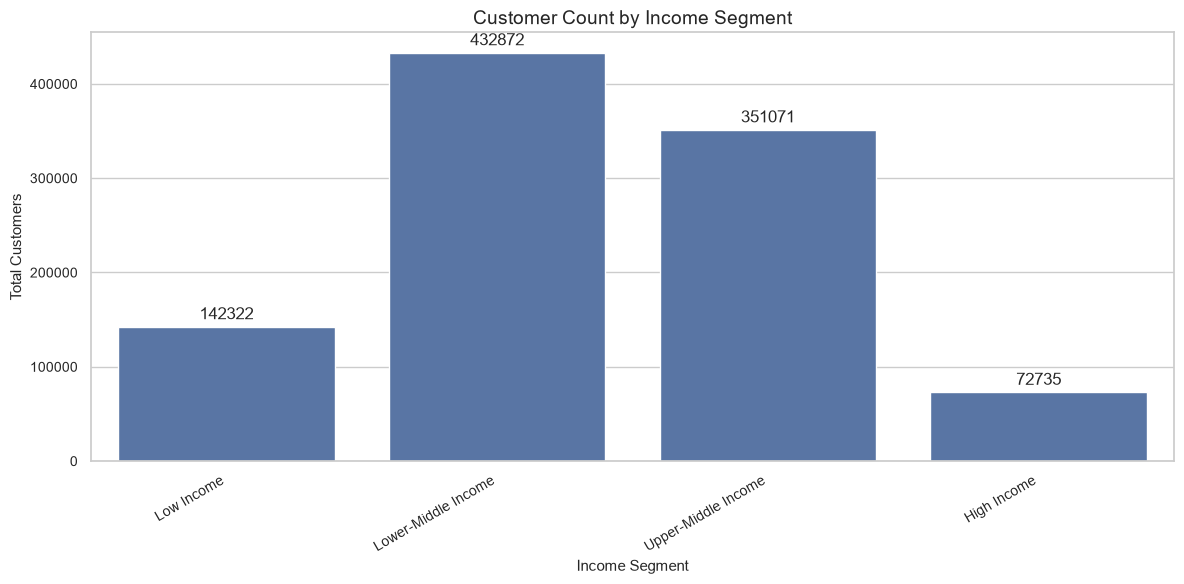

In [6]:
segment_plot = segment_analysis.sort_values(
    "TotalCustomers",
    ascending=False
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_plot,
    x="IncomeSegment",
    y="TotalCustomers"
)

plt.title("Customer Count by Income Segment")
plt.xlabel("Income Segment")
plt.ylabel("Total Customers")
plt.xticks(rotation=30, ha="right")

for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

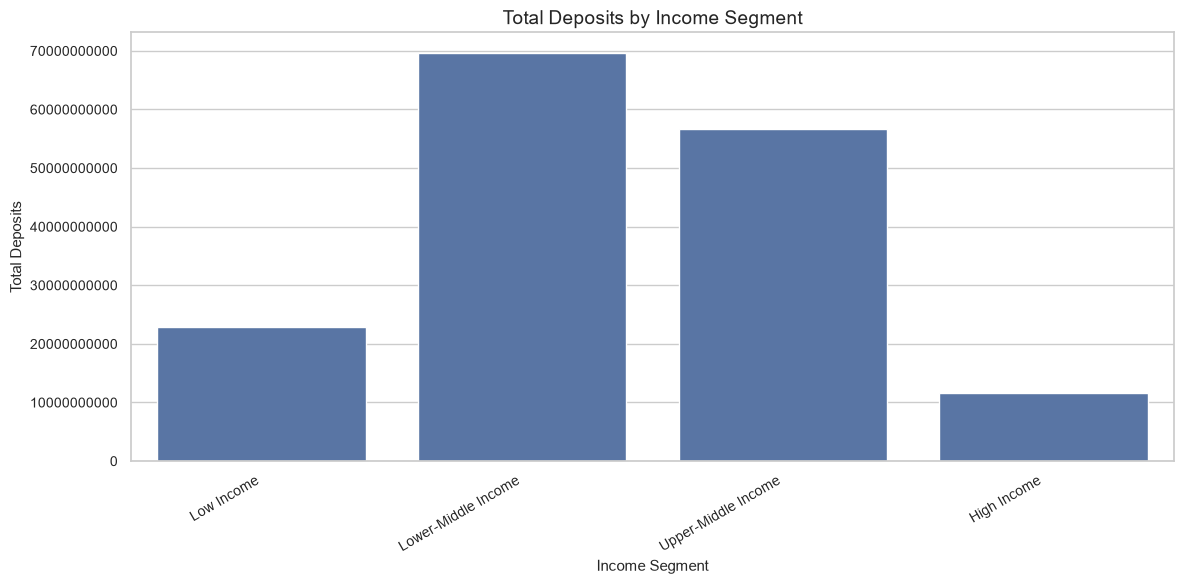

In [7]:
segment_plot = segment_analysis.sort_values(
    "TotalDeposits",
    ascending=False
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_plot,
    x="IncomeSegment",
    y="TotalDeposits"
)

plt.title("Total Deposits by Income Segment")
plt.xlabel("Income Segment")
plt.ylabel("Total Deposits")
plt.xticks(rotation=30, ha="right")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.tight_layout()
plt.show()

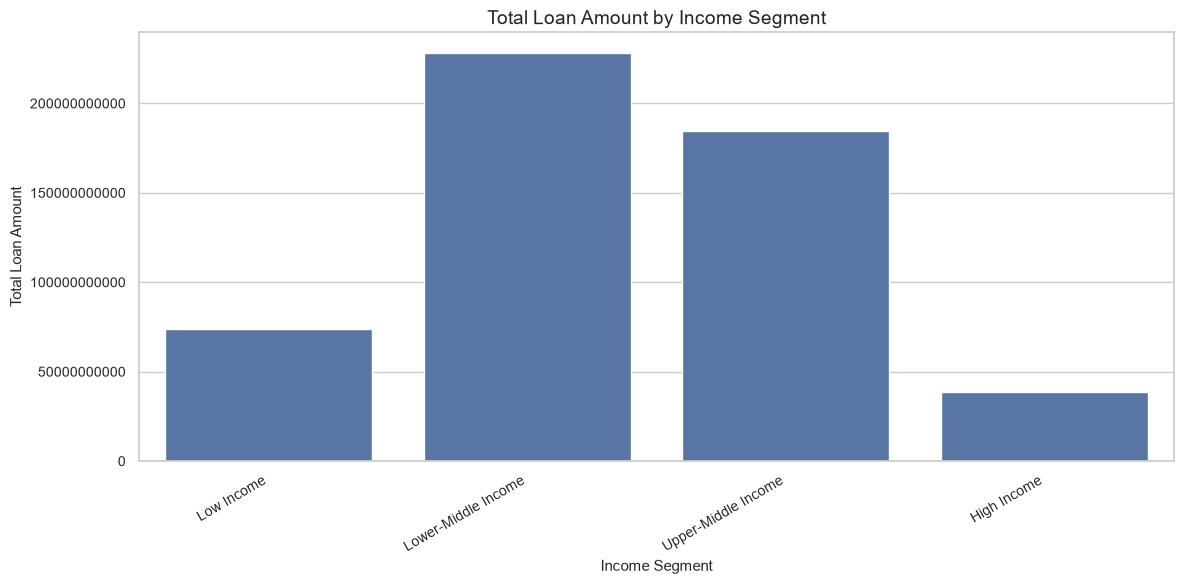

In [8]:
segment_plot = segment_analysis.sort_values(
    "TotalLoans",
    ascending=False
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_plot,
    x="IncomeSegment",
    y="TotalLoans"
)

plt.title("Total Loan Amount by Income Segment")
plt.xlabel("Income Segment")
plt.ylabel("Total Loan Amount")
plt.xticks(rotation=30, ha="right")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.tight_layout()
plt.show()

### Business Answer – Question 16

The Lower-Middle Income segment contributes the largest
share of total deposits (43.30%) and total loans (43.47%).

It also has the highest customer count, with 432,872 customers.
The Upper-Middle Income segment is the second-largest contributor,
accounting for 35.21% of deposits and 35.12% of loans.

Although the High Income segment has the highest average income,
it contributes only 7.27% of total deposits.

Based on the analyzed deposit and loan contributions,
the Lower-Middle Income segment represents the largest
customer segment in the bank's current portfolio.

## Business Question 17: Which Branch Generates the Highest Deposits?

### Objective
To identify the branch that generates the highest total deposits
by analyzing account balances across all bank branches.

### Business Purpose
This analysis helps the bank compare deposit contributions
across branches and identify branches with the highest
deposit volumes.

### Step 1: Calculate Total Deposits by Branch

Group account records by branch and calculate the total
account balance for each branch.

Sort the results in descending order to identify the branch
with the highest total deposits.

In [9]:
branch_deposits = (
    accounts.groupby("Branch", as_index=False)
    .agg(
        TotalDeposits=("Balance", "sum"),
        TotalAccounts=("AccountID", "nunique"),
        AverageAccountBalance=("Balance", "mean")
    )
)

branch_deposits = branch_deposits.sort_values(
    by="TotalDeposits",
    ascending=False
).reset_index(drop=True)

branch_deposits

,Branch,TotalDeposits,TotalAccounts,AverageAccountBalance
0,BR039,3.274654e+09,26067,125624.521153
1,BR047,3.267667e+09,26177,124829.705233
2,BR012,3.265131e+09,26148,124871.150961
3,BR027,3.260816e+09,25972,125551.203497
4,BR007,3.258398e+09,25906,125777.744831
5,BR018,3.258341e+09,26384,123496.855788
6,BR014,3.241991e+09,26077,124323.787887
7,BR037,3.240730e+09,26175,123810.133280
8,BR022,3.236912e+09,26177,123654.802735
9,BR011,3.232968e+09,26300,122926.529231


### Step 2: Identify the Branch with the Highest Deposits

Sort the branches by total deposits and select the branch
with the highest deposit amount.

In [10]:
highest_deposit_branch = branch_deposits.iloc[0]

print("Branch:", highest_deposit_branch["Branch"])
print(
    "Total Deposits:",
    round(highest_deposit_branch["TotalDeposits"], 2)
)
print(
    "Total Accounts:",
    highest_deposit_branch["TotalAccounts"]
)
print(
    "Average Account Balance:",
    round(
        highest_deposit_branch["AverageAccountBalance"],
        2
    )
)

Branch: BR039
Total Deposits: 3274654392.89
Total Accounts: 26067
Average Account Balance: 125624.52


## BQ17: Branch Deposit Performance

This visualization displays the ten branches with the
highest total deposits.

The chart helps compare deposit contributions across
the leading branches.

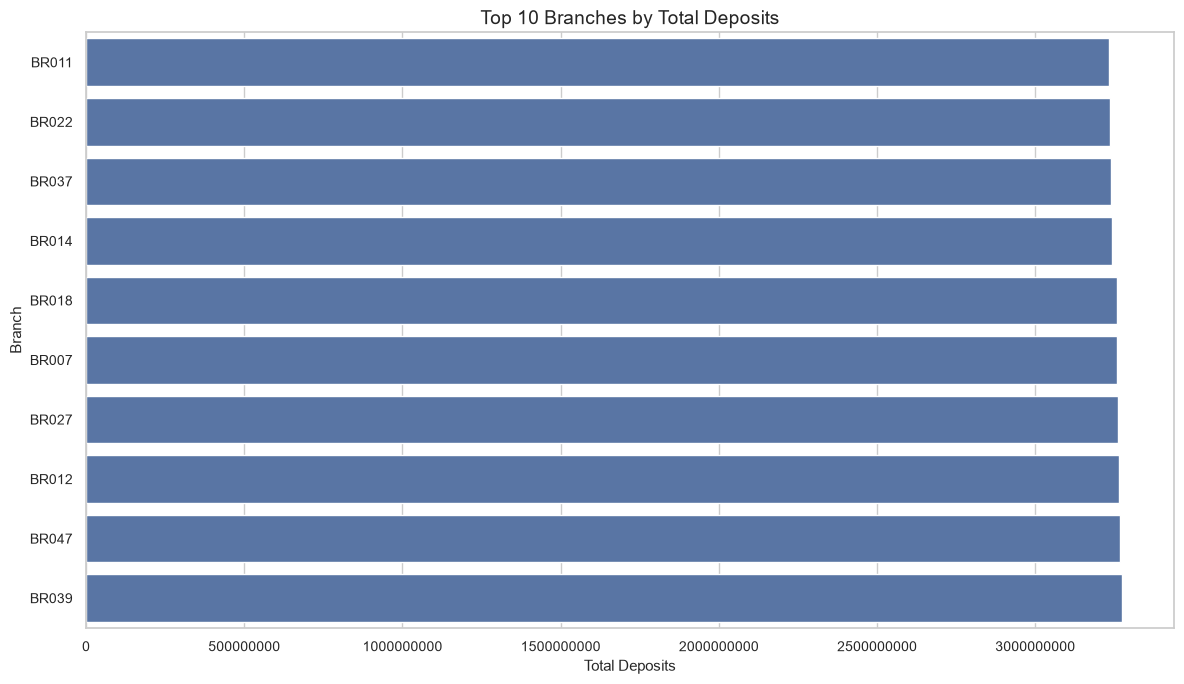

In [11]:
top_10_branches = branch_deposits.nlargest(
    10,
    "TotalDeposits"
).sort_values(
    "TotalDeposits",
    ascending=True
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10_branches,
    x="TotalDeposits",
    y="Branch"
)

plt.title("Top 10 Branches by Total Deposits")
plt.xlabel("Total Deposits")
plt.ylabel("Branch")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

### Business Answer – Question 17

Branch BR039 generates the highest total deposits,
with approximately 3.27 billion in account balances
across 26,067 accounts.

It has an average account balance of approximately
125,624.52.

Branch BR047 and BR012 rank second and third,
respectively, in total deposits.

Branch BR039 contributes the largest deposit volume
among the 50 branches in the dataset.

### Business Insight

Branch BR039 has the highest total deposits among
the 50 branches analyzed.

The bank can examine this branch's customer base,
deposit products, and operating practices to understand
the factors associated with its high deposit volume.

Branches with lower deposits may also be reviewed
to identify opportunities for improvement.

## Business Question 18: Which Branch Has the Highest Loan Activity?

### Objective
To identify the branch with the highest loan activity by
analyzing the number and total amount of loans associated
with each branch.

### Business Purpose
This analysis helps the bank compare loan activity across
branches and understand the distribution of its loan portfolio.

### Step 1: Map Customers to Branches

Use the CustomerID and Branch columns from the accounts
dataset to associate customers with their branches.

Merge this information with the loans dataset to analyze
loan activity by branch.

In [12]:
# Get customer and branch mapping from accounts
customer_branch = (
    accounts[["CustomerID", "Branch"]]
    .drop_duplicates()
)

# Merge customer branch information with loans
branch_loans = loans.merge(
    customer_branch,
    on="CustomerID",
    how="inner"
)

branch_loans.head()

,LoanID,CustomerID,LoanType,LoanAmount,InterestRate,LoanDate,LoanStatus,RepaymentAmount,Branch
0,1,974491,Home,652731.51,7.58,2021-06-22,Approved,266193.75,BR044
1,1,974491,Home,652731.51,7.58,2021-06-22,Approved,266193.75,BR019
2,1,974491,Home,652731.51,7.58,2021-06-22,Approved,266193.75,BR049
3,2,283305,Business,1439009.61,11.69,2024-07-26,Approved,834606.07,BR005
4,4,385523,Auto,617687.75,16.17,2025-06-12,Approved,59459.23,BR024


### Step 2: Calculate Loan Activity by Branch

Calculate the total number of loans, total loan amount,
and average loan amount for each branch.

Sort the results by total loan amount in descending order
to identify the branch with the highest loan activity.

In [13]:
branch_loan_analysis = (
    branch_loans.groupby("Branch", as_index=False)
    .agg(
        TotalLoans=("LoanID", "nunique"),
        TotalLoanAmount=("LoanAmount", "sum"),
        AverageLoanAmount=("LoanAmount", "mean")
    )
    .sort_values(
        by="TotalLoanAmount",
        ascending=False
    )
    .reset_index(drop=True)
)

branch_loan_analysis

,Branch,TotalLoans,TotalLoanAmount,AverageLoanAmount
0,BR024,13036,1.391533e+10,1.067454e+06
1,BR010,13094,1.386628e+10,1.058979e+06
2,BR004,13214,1.379524e+10,1.043986e+06
3,BR048,13055,1.378599e+10,1.055993e+06
4,BR015,12904,1.375014e+10,1.065572e+06
5,BR022,13054,1.374512e+10,1.052943e+06
6,BR012,13138,1.371892e+10,1.044217e+06
7,BR017,12878,1.370312e+10,1.064072e+06
8,BR011,12921,1.366701e+10,1.057736e+06
9,BR003,12861,1.365622e+10,1.061832e+06


### Step 3: Identify the Branch with the Highest Loan Activity

Select the branch with the highest total loan amount
and display its loan count and average loan amount.

In [14]:
highest_loan_branch = branch_loan_analysis.iloc[0]

print("Branch:", highest_loan_branch["Branch"])
print("Total Loans:", highest_loan_branch["TotalLoans"])
print(
    "Total Loan Amount:",
    round(highest_loan_branch["TotalLoanAmount"], 2)
)
print(
    "Average Loan Amount:",
    round(highest_loan_branch["AverageLoanAmount"], 2)
)

Branch: BR024
Total Loans: 13036
Total Loan Amount: 13915333619.72
Average Loan Amount: 1067454.25


## BQ18: Branch Loan Activity

This visualization compares branch-associated loan activity
using the existing branch_loan_analysis DataFrame.

Important limitation:
Loans are linked to branches through customers' accounts.
A customer may have accounts in multiple branches, so the
same loan may be attributed to multiple branches.

Therefore, this chart should not be interpreted as a
confirmed count of loans originated by each branch.

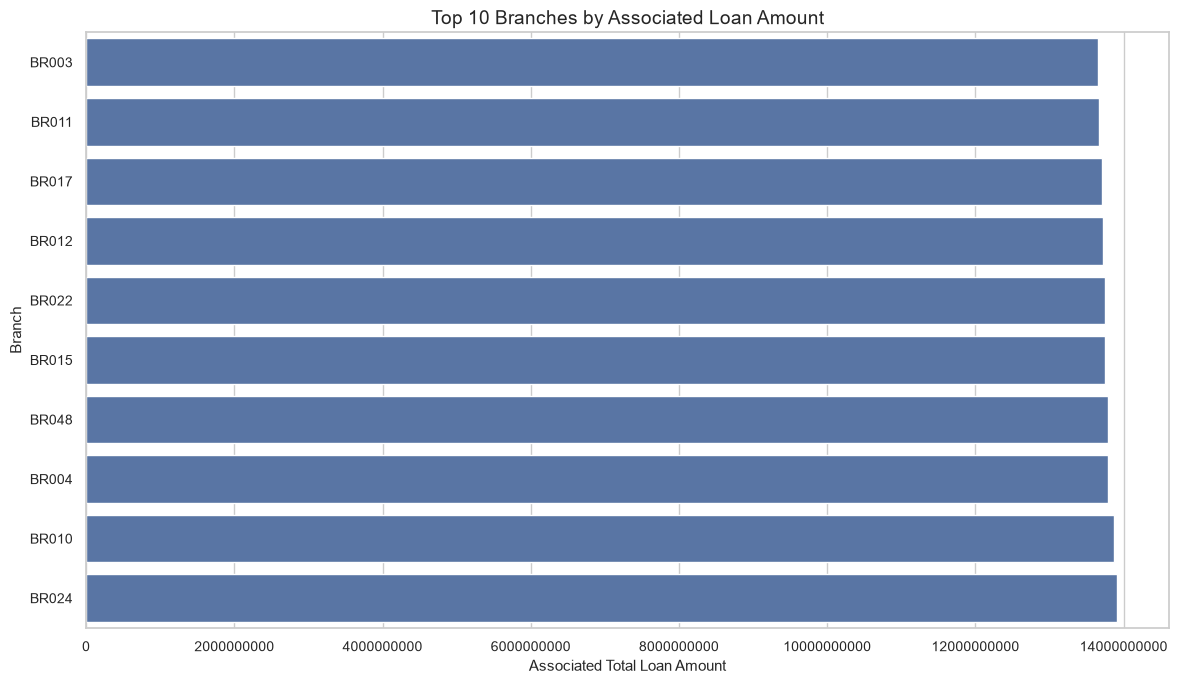

In [15]:
top_10_branch_loans = branch_loan_analysis.nlargest(
    10,
    "TotalLoanAmount"
).sort_values(
    "TotalLoanAmount",
    ascending=True
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10_branch_loans,
    x="TotalLoanAmount",
    y="Branch"
)

plt.title(
    "Top 10 Branches by Associated Loan Amount"
)
plt.xlabel("Associated Total Loan Amount")
plt.ylabel("Branch")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

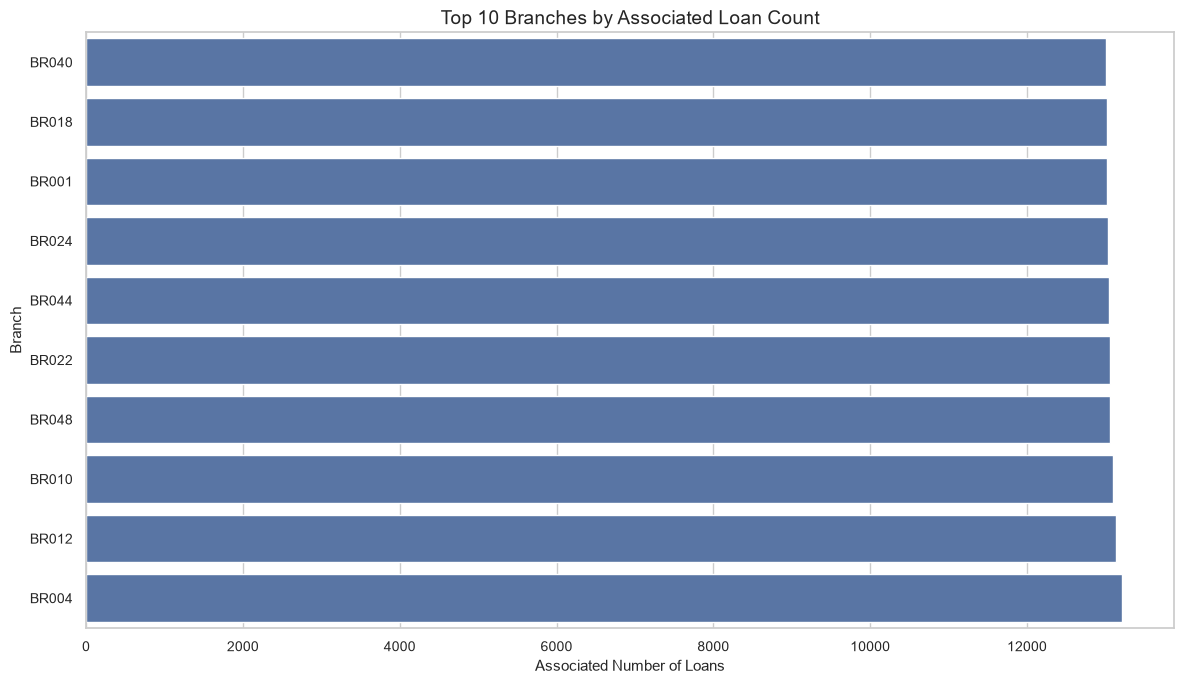

In [16]:
top_10_branch_loan_counts = branch_loan_analysis.nlargest(
    10,
    "TotalLoans"
).sort_values(
    "TotalLoans",
    ascending=True
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10_branch_loan_counts,
    x="TotalLoans",
    y="Branch"
)

plt.title(
    "Top 10 Branches by Associated Loan Count"
)
plt.xlabel("Associated Number of Loans")
plt.ylabel("Branch")

plt.tight_layout()
plt.show()

### Business Answer – Question 18

Branch BR024 has the highest total loan amount,
with approximately 13.92 billion in loans and
an average loan amount of approximately 1,067,454.

Branch BR010 has the highest number of loans,
with 13,094 loans, followed by BR004 with 13,214
loans? 

Based on total loan amount, BR024 ranks first,
followed by BR010 and BR004.

These results are based on associating loans with
branches through customer account information.
Customers with accounts at multiple branches may
cause loans to be counted under more than one branch.

### Business Insight

Branch BR024 has the largest total loan amount
in the branch-level analysis, while BR010 has
the highest number of loans.

This indicates that the branch with the largest
loan portfolio by value is not necessarily the
branch with the most loans.

The bank can review both loan volume and loan
amount when comparing branch-level loan activity.

## Business Question 19: Which loan type is most popular?

### Objective
The objective of this analysis is to identify the most popular loan type
based on the number of loans issued.

### Key Metrics
- Total number of loans by loan type
- Percentage share of each loan type
- Most popular loan type

### Expected Outcome
Identify which loan type has the highest number of loans and understand
the distribution of loans across different loan types.

In [17]:
# Count the number of loans for each loan type

loan_type_counts = (
    loans.groupby("LoanType")
    .size()
    .reset_index(name="TotalLoans")
)

loan_type_counts = loan_type_counts.sort_values(
    by="TotalLoans",
    ascending=False
)

loan_type_counts

,LoanType,TotalLoans
5,Personal,140045
4,Home,90614
2,Business,84806
1,Auto,74399
3,Education,60085
0,Agriculture,50051


In [18]:
# Calculate the percentage share of each loan type

total_loans = loan_type_counts["TotalLoans"].sum()

loan_type_counts["LoanPercentage"] = (
    loan_type_counts["TotalLoans"] / total_loans
) * 100

loan_type_counts

,LoanType,TotalLoans,LoanPercentage
5,Personal,140045,28.0090
4,Home,90614,18.1228
2,Business,84806,16.9612
1,Auto,74399,14.8798
3,Education,60085,12.0170
0,Agriculture,50051,10.0102


In [19]:
# Identify the loan type with the highest number of loans

most_popular_loan = loan_type_counts.iloc[0]

print("Most Popular Loan Type:", most_popular_loan["LoanType"])
print("Total Loans:", most_popular_loan["TotalLoans"])
print(
    "Loan Percentage:",
    round(most_popular_loan["LoanPercentage"], 2),
    "%"
)

Most Popular Loan Type: Personal
Total Loans: 140045
Loan Percentage: 28.01 %


## BQ19: Loan Type Popularity

This visualization compares the number of loans across
different loan types.

The percentage labels show each loan type's share of
the total number of loans.

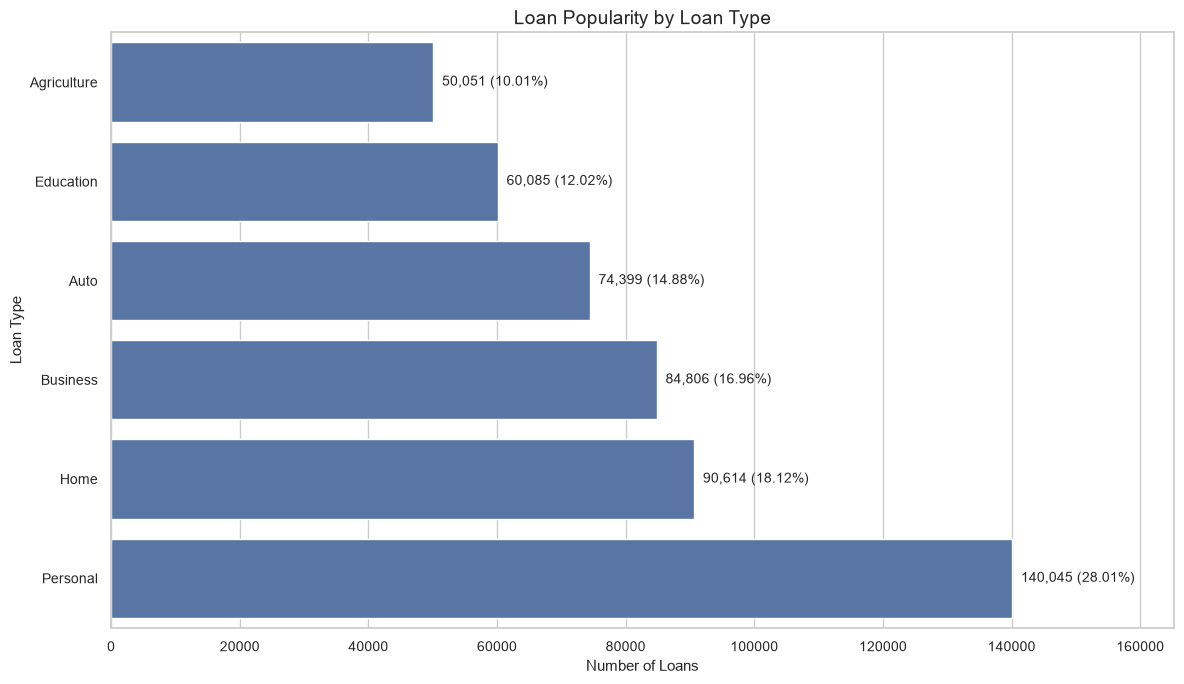

In [20]:
loan_type_plot = loan_type_counts.sort_values(
    "TotalLoans",
    ascending=True
).copy()

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=loan_type_plot,
    x="TotalLoans",
    y="LoanType"
)

plt.title("Loan Popularity by Loan Type")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Type")

# Add space on the right for labels
max_loans = loan_type_plot["TotalLoans"].max()
ax.set_xlim(0, max_loans * 1.18)

# Display count and percentage together
for i, row in enumerate(loan_type_plot.itertuples(index=False)):
    ax.text(
        row.TotalLoans + max_loans * 0.01,
        i,
        f"{row.TotalLoans:,} ({row.LoanPercentage:.2f}%)",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Business Answer

The most popular loan type is the loan category with the highest number
of loans in the dataset.

The analysis identifies Personal Loans as the most popular loan type,
with 140,045 loans, accounting for 28.01% of total loans. Home Loans
rank second with 90,614 loans, followed by Business Loans with 84,806
loans.

This information helps the bank understand customer borrowing patterns
and identify loan products with higher demand.

## Business Question 20: Which customers have the highest loan exposure?

### Objective
The objective of this analysis is to identify customers with the
highest total loan exposure based on their loan amounts.

### Key Metrics
- Total loan amount per customer
- Number of loans per customer
- Average loan amount per customer
- Top customers by total loan exposure

### Expected Outcome
Identify customers with the highest loan exposure and understand
the distribution of loan amounts among them.

In [21]:
# Calculate total loan exposure for each customer

customer_loan_exposure = (
    loans.groupby("CustomerID")
    .agg(
        TotalLoanExposure=("LoanAmount", "sum"),
        TotalLoans=("LoanID", "count"),
        AverageLoanAmount=("LoanAmount", "mean")
    )
    .reset_index()
)

customer_loan_exposure.head()

,CustomerID,TotalLoanExposure,TotalLoans,AverageLoanAmount
0,1,1379561.94,1,1379561.94
1,7,8463415.56,2,4231707.78
2,11,2744317.20,1,2744317.20
3,14,4844435.70,3,1614811.90
4,15,894168.20,1,894168.20


In [22]:
# Sort customers by total loan exposure

top_10_loan_exposure = (
    customer_loan_exposure
    .sort_values(
        by="TotalLoanExposure",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

top_10_loan_exposure

,CustomerID,TotalLoanExposure,TotalLoans,AverageLoanAmount
0,252802,34752151.04,3,1.158405e+07
1,506279,32380483.93,3,1.079349e+07
2,513481,30716706.62,2,1.535835e+07
3,108276,30561316.02,2,1.528066e+07
4,375221,30000000.00,1,3.000000e+07
5,978220,30000000.00,1,3.000000e+07
6,537465,30000000.00,1,3.000000e+07
7,601789,29407445.80,1,2.940745e+07
8,926680,27239171.65,1,2.723917e+07
9,498041,26668153.84,1,2.666815e+07


In [23]:
# Identify the customer with the highest loan exposure

highest_loan_customer = top_10_loan_exposure.iloc[0]

print("Customer ID:", highest_loan_customer["CustomerID"])
print(
    "Total Loan Exposure:",
    round(highest_loan_customer["TotalLoanExposure"], 2)
)
print("Total Loans:", highest_loan_customer["TotalLoans"])
print(
    "Average Loan Amount:",
    round(highest_loan_customer["AverageLoanAmount"], 2)
)

Customer ID: 252802.0
Total Loan Exposure: 34752151.04
Total Loans: 3.0
Average Loan Amount: 11584050.35


## BQ20: Customer Loan Exposure

This visualization displays the ten customers with the
highest total loan amounts.

Total loan amount is used as a proxy for loan exposure.
It does not necessarily represent the outstanding loan balance.

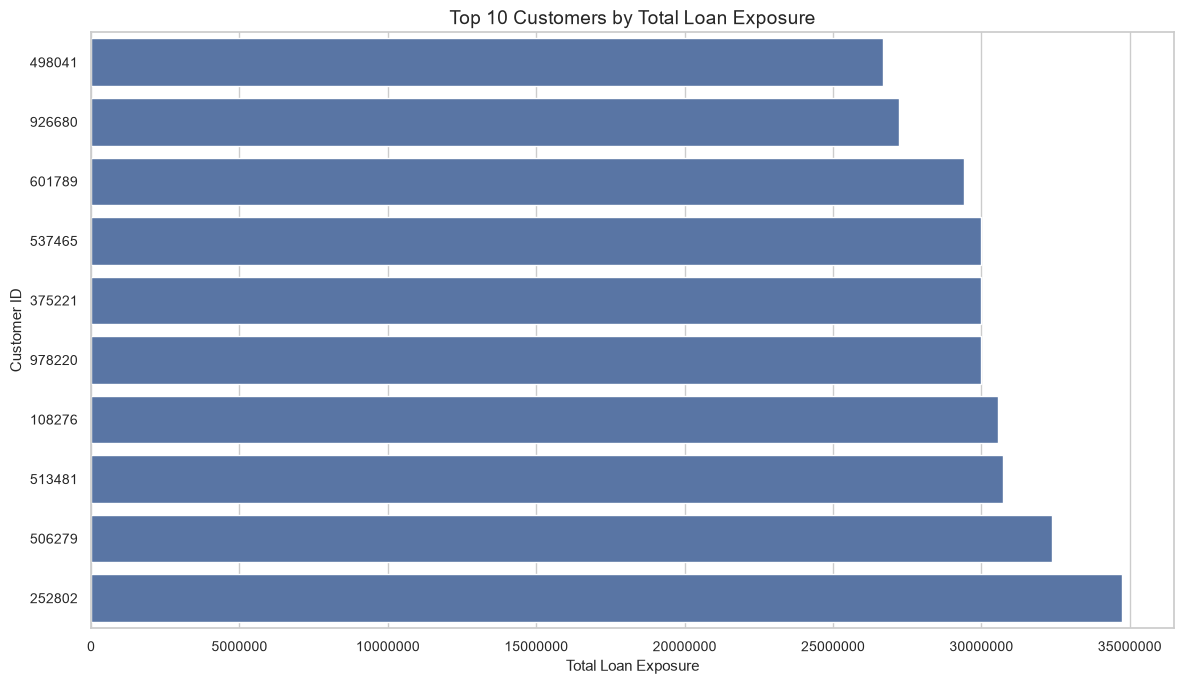

In [24]:
top_10_exposure_plot = top_10_loan_exposure.sort_values(
    "TotalLoanExposure",
    ascending=True
).copy()

top_10_exposure_plot["CustomerID"] = (
    top_10_exposure_plot["CustomerID"].astype(str)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10_exposure_plot,
    x="TotalLoanExposure",
    y="CustomerID"
)

plt.title("Top 10 Customers by Total Loan Exposure")
plt.xlabel("Total Loan Exposure")
plt.ylabel("Customer ID")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

### Business Answer

Customers with the highest loan exposure are those who have the
largest total loan amounts in the dataset.

The analysis identifies CustomerID 252802 as having the highest
loan exposure, with a total of 34,752,151.04 across 3 loans.
CustomerID 506279 ranks second, with a total loan exposure of
32,380,483.93 across 3 loans.

This information helps the bank identify customers with large
loan exposures and monitor its loan portfolio concentration.

## Business Question 21: Are high-income customers taking larger loans?

### Objective
The objective of this analysis is to examine the relationship between
customer income and loan amounts to determine whether high-income
customers tend to take larger loans.

### Key Metrics
- Customer income
- Total loan amount
- Average loan amount by income group
- Number of loans by income group

### Expected Outcome
Understand the relationship between customer income and loan amounts
and identify differences in borrowing patterns across income groups.

In [25]:
# Merge customer information with loan records

customer_loan_data = customers[
    ["CustomerID", "Income"]
].merge(
    loans[["CustomerID", "LoanAmount"]],
    on="CustomerID",
    how="inner"
)

customer_loan_data.head()

,CustomerID,Income,LoanAmount
0,1,100160.69,1379561.94
1,7,53891.49,782029.62
2,7,53891.49,7681385.94
3,11,28695.21,2744317.20
4,14,34792.99,2700601.97


In [26]:
# Divide customers into income groups

income_bins = [0, 25000, 50000, 100000, float("inf")]

income_labels = [
    "Low Income",
    "Lower-Middle Income",
    "Upper-Middle Income",
    "High Income"
]

customer_loan_data["IncomeGroup"] = pd.cut(
    customer_loan_data["Income"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

customer_loan_data.head()

,CustomerID,Income,LoanAmount,IncomeGroup
0,1,100160.69,1379561.94,High Income
1,7,53891.49,782029.62,Upper-Middle Income
2,7,53891.49,7681385.94,Upper-Middle Income
3,11,28695.21,2744317.20,Lower-Middle Income
4,14,34792.99,2700601.97,Lower-Middle Income


In [27]:
# Calculate loan metrics for each income group

income_loan_analysis = (
    customer_loan_data.groupby("IncomeGroup", observed=False)
    .agg(
        TotalCustomers=("CustomerID", "nunique"),
        TotalLoans=("LoanAmount", "count"),
        AverageIncome=("Income", "mean"),
        TotalLoanAmount=("LoanAmount", "sum"),
        AverageLoanAmount=("LoanAmount", "mean")
    )
    .reset_index()
)

income_loan_analysis

,IncomeGroup,TotalCustomers,TotalLoans,AverageIncome,TotalLoanAmount,AverageLoanAmount
0,Low Income,55735,70944,19461.288576,7.398551e+10,1.042872e+06
1,Lower-Middle Income,170512,217500,37156.267130,2.282322e+11,1.049344e+06
2,Upper-Middle Income,137903,175522,68085.462439,1.843880e+11,1.050512e+06
3,High Income,28581,36557,131048.882181,3.837592e+10,1.049756e+06


In [28]:
# Sort income groups by average loan amount

income_loan_analysis = income_loan_analysis.sort_values(
    by="AverageLoanAmount",
    ascending=False
).reset_index(drop=True)

income_loan_analysis[
    ["IncomeGroup", "TotalLoans", "AverageIncome", "AverageLoanAmount"]
]

,IncomeGroup,TotalLoans,AverageIncome,AverageLoanAmount
0,Upper-Middle Income,175522,68085.462439,1.050512e+06
1,High Income,36557,131048.882181,1.049756e+06
2,Lower-Middle Income,217500,37156.267130,1.049344e+06
3,Low Income,70944,19461.288576,1.042872e+06


## BQ21: Customer Income and Loan Amount Analysis

The first visualization examines the relationship between
customer income and loan amount.

The second visualization compares average loan amounts
across income groups.

These charts describe associations in the available data.
They do not establish that income causes larger loans.

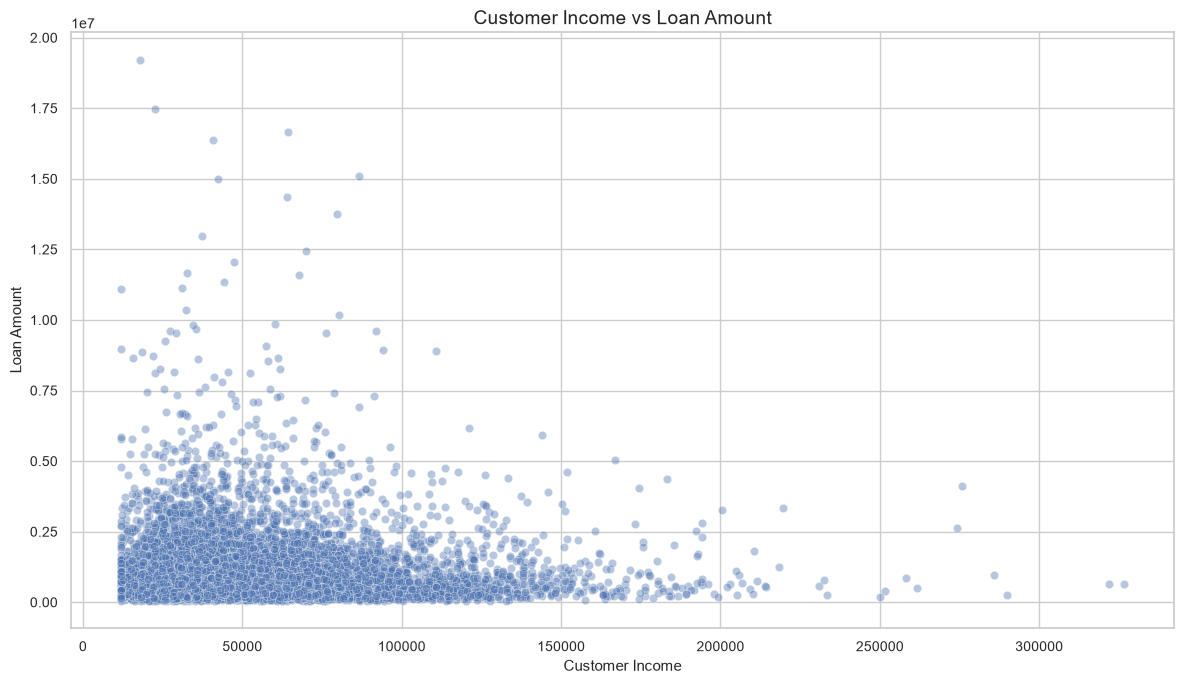

In [29]:
scatter_data = customer_loan_data[
    ["Income", "LoanAmount"]
].dropna()

scatter_sample = scatter_data.sample(
    n=min(10000, len(scatter_data)),
    random_state=42
)

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=scatter_sample,
    x="Income",
    y="LoanAmount",
    alpha=0.4
)

plt.title("Customer Income vs Loan Amount")
plt.xlabel("Customer Income")
plt.ylabel("Loan Amount")

plt.tight_layout()
plt.show()

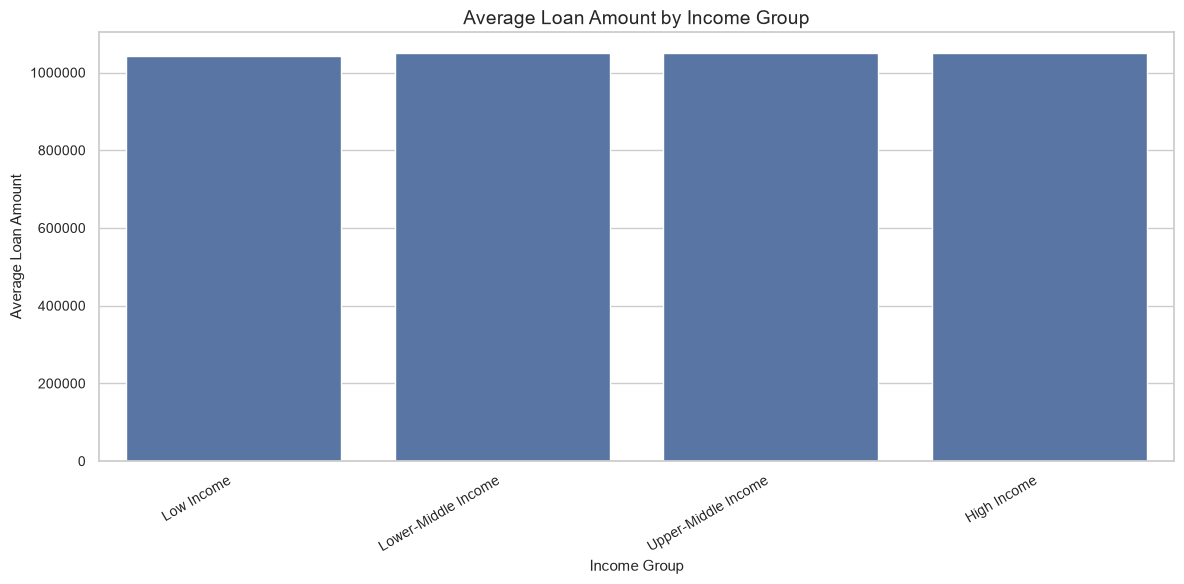

In [30]:
income_loan_plot = income_loan_analysis.sort_values(
    "AverageLoanAmount",
    ascending=False
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=income_loan_plot,
    x="IncomeGroup",
    y="AverageLoanAmount"
)

plt.title("Average Loan Amount by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Loan Amount")
plt.xticks(rotation=30, ha="right")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.tight_layout()
plt.show()

### Business Answer

The analysis examines whether high-income customers take larger loans
by comparing the average loan amounts across different income groups.

The results show that Upper-Middle Income customers have the highest
average loan amount of approximately 1,050,512, followed by High Income
customers with approximately 1,049,756. Low Income customers have the
lowest average loan amount of approximately 1,042,872.

This information indicates that average loan amounts are relatively
similar across all income groups. Therefore, higher income does not
necessarily correspond to larger loans in this dataset.

## Business Question 22: Which branches have high deposits but low loan activity?

### Objective
The objective of this analysis is to identify branches with high
deposit amounts but relatively low loan activity.

### Key Metrics
- Total deposits by branch
- Number of loans by branch
- Total loan amount by branch
- Branch deposit and loan activity comparison

### Expected Outcome
Identify branches with high deposits and low loan activity to help
the bank understand differences in deposit collection and lending
activity across branches.

Note: The loans dataset does not contain a Branch column. Therefore,
loan activity is assigned using each customer's primary account
branch, based on the account with the highest balance. This is a
proxy and may not represent the actual loan-originating branch.

In [31]:
# Calculate total deposits for each branch

branch_deposits = (
    accounts.groupby("Branch")
    .agg(
        TotalDeposits=("Balance", "sum"),
        TotalAccounts=("AccountID", "nunique")
    )
    .reset_index()
)

branch_deposits.head()

,Branch,TotalDeposits,TotalAccounts
0,BR001,3.229943e+09,26060
1,BR002,3.200864e+09,25909
2,BR003,3.227174e+09,26199
3,BR004,3.212397e+09,26262
4,BR005,3.187892e+09,25768


In [32]:
# Assign each customer to the branch of their highest-balance account

customer_primary_branch = (
    accounts.sort_values(
        by="Balance",
        ascending=False
    )
    .drop_duplicates(subset="CustomerID")
    [["CustomerID", "Branch"]]
)

customer_primary_branch.head()

,CustomerID,Branch
424488,214258,BR025
465031,439220,BR018
886360,514215,BR004
457935,438313,BR045
1163890,693624,BR023


In [33]:
# Map each customer's loans to their primary account branch

loans_with_branch = loans.merge(
    customer_primary_branch,
    on="CustomerID",
    how="left"
)

# Calculate loan activity by branch

branch_loan_activity = (
    loans_with_branch.groupby("Branch")
    .agg(
        TotalLoans=("LoanID", "nunique"),
        TotalLoanAmount=("LoanAmount", "sum")
    )
    .reset_index()
)

branch_loan_activity.head()

,Branch,TotalLoans,TotalLoanAmount
0,BR001,7433,7.824284e+09
1,BR002,7179,7.560691e+09
2,BR003,7259,7.697626e+09
3,BR004,7616,7.973243e+09
4,BR005,7162,7.520819e+09


In [34]:
# Combine branch deposits and loan activity

branch_deposit_loan = branch_deposits.merge(
    branch_loan_activity,
    on="Branch",
    how="left"
)

branch_deposit_loan[
    ["TotalLoans", "TotalLoanAmount"]
] = branch_deposit_loan[
    ["TotalLoans", "TotalLoanAmount"]
].fillna(0)

branch_deposit_loan.head()

,Branch,TotalDeposits,TotalAccounts,TotalLoans,TotalLoanAmount
0,BR001,3.229943e+09,26060,7433,7.824284e+09
1,BR002,3.200864e+09,25909,7179,7.560691e+09
2,BR003,3.227174e+09,26199,7259,7.697626e+09
3,BR004,3.212397e+09,26262,7616,7.973243e+09
4,BR005,3.187892e+09,25768,7162,7.520819e+09


In [35]:
# Define thresholds using the median across branches

high_deposit_threshold = branch_deposit_loan[
    "TotalDeposits"
].median()

low_loan_activity_threshold = branch_deposit_loan[
    "TotalLoans"
].median()

# Identify branches with high deposits and low loan activity

high_deposit_low_loan = branch_deposit_loan[
    (branch_deposit_loan["TotalDeposits"] >= high_deposit_threshold) &
    (branch_deposit_loan["TotalLoans"] <= low_loan_activity_threshold)
].copy()

# Sort by total deposits

high_deposit_low_loan = high_deposit_low_loan.sort_values(
    by="TotalDeposits",
    ascending=False
).reset_index(drop=True)

high_deposit_low_loan

,Branch,TotalDeposits,TotalAccounts,TotalLoans,TotalLoanAmount
0,BR027,3.260816e+09,25972,7215,7.514274e+09
1,BR007,3.258398e+09,25906,7178,7.558338e+09
2,BR014,3.241991e+09,26077,7253,7.640849e+09
3,BR049,3.232844e+09,25953,7227,7.611060e+09
4,BR035,3.230663e+09,26012,7059,7.287480e+09
5,BR030,3.228245e+09,26145,7228,7.729784e+09
6,BR003,3.227174e+09,26199,7259,7.697626e+09
7,BR019,3.221074e+09,26023,7194,7.469976e+09


## BQ22: High Deposit and Low Loan Activity

This scatter plot compares total deposits and loan activity
across branches.

The vertical and horizontal reference lines represent the
median deposit and loan activity thresholds used in the
existing analysis.

Branches in the high-deposit and low-loan-activity area
are highlighted.

Note: Branch loan activity is based on the existing
customer-primary-branch assignment method.

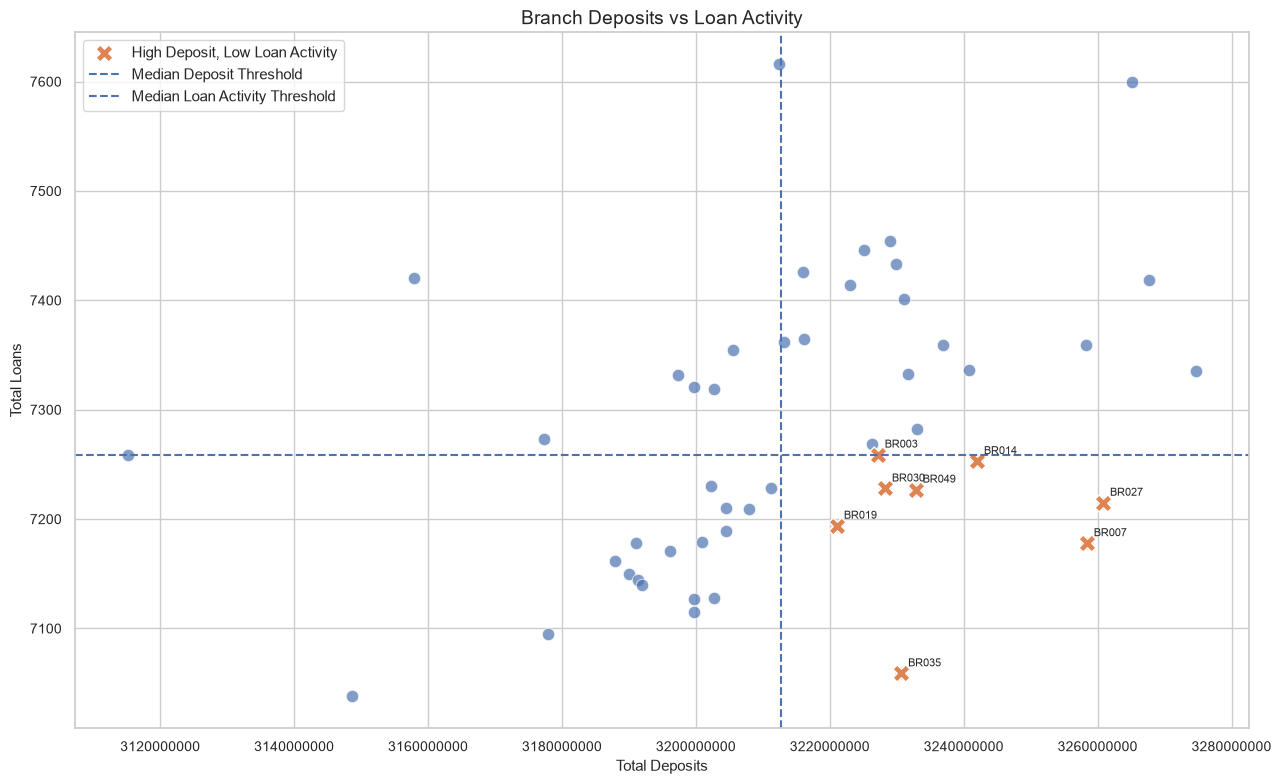

In [36]:
plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=branch_deposit_loan,
    x="TotalDeposits",
    y="TotalLoans",
    s=80,
    alpha=0.7
)

sns.scatterplot(
    data=high_deposit_low_loan,
    x="TotalDeposits",
    y="TotalLoans",
    s=150,
    marker="X",
    label="High Deposit, Low Loan Activity"
)

plt.axvline(
    high_deposit_threshold,
    linestyle="--",
    label="Median Deposit Threshold"
)

plt.axhline(
    low_loan_activity_threshold,
    linestyle="--",
    label="Median Loan Activity Threshold"
)

for _, row in high_deposit_low_loan.iterrows():
    plt.annotate(
        row["Branch"],
        (
            row["TotalDeposits"],
            row["TotalLoans"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Branch Deposits vs Loan Activity")
plt.xlabel("Total Deposits")
plt.ylabel("Total Loans")
plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.legend()
plt.tight_layout()
plt.show()

### Business Answer

Branches with high deposits but low loan activity are identified by
comparing their total deposits and number of loans.

The analysis identifies BR027 as having the highest deposits among
the branches with relatively low loan activity, with total deposits
of approximately 3.26 billion and 7,215 loans. BR035 also shows
high deposits of approximately 3.23 billion and relatively low
loan activity, with 7,059 loans.

This information helps the bank identify branches with high deposit
collection but comparatively low lending activity and may support
further investigation of branch-level operations.

Note: Loan activity is assigned using customers' primary account
branches because the loans dataset does not contain branch
information. Therefore, the results are estimates and may not
represent actual loan-originating branches.

## Business Question 23: Which customers may represent higher repayment risk?

### Objective
The objective of this analysis is to identify customers who may
represent higher repayment risk based on their loan status and
repayment information.

### Key Metrics
- Total loan amount per customer
- Total repayment amount per customer
- Number of loans per customer
- Loan status
- Repayment ratio

### Expected Outcome
Identify customers with potentially higher repayment risk based
on available loan and repayment information.

Note: The dataset does not provide a dedicated default indicator.
Therefore, this analysis identifies potential risk indicators
rather than confirmed loan defaults.

In [37]:
# Calculate repayment metrics for each customer

customer_repayment_risk = (
    loans.groupby("CustomerID")
    .agg(
        TotalLoans=("LoanID", "nunique"),
        TotalLoanAmount=("LoanAmount", "sum"),
        TotalRepaymentAmount=("RepaymentAmount", "sum")
    )
    .reset_index()
)

customer_repayment_risk["RepaymentRatio"] = (
    customer_repayment_risk["TotalRepaymentAmount"] /
    customer_repayment_risk["TotalLoanAmount"].replace(0, np.nan)
) * 100

customer_repayment_risk.head()

,CustomerID,TotalLoans,TotalLoanAmount,TotalRepaymentAmount,RepaymentRatio
0,1,1,1379561.94,489183.30,35.459321
1,7,2,8463415.56,5706711.08,67.427991
2,11,1,2744317.20,653183.01,23.801294
3,14,3,4844435.70,1447842.99,29.886721
4,15,1,894168.20,687464.20,76.883096


In [38]:
# Analyze loan status for each customer

customer_loan_status = (
    loans.groupby("CustomerID")
    .agg(
        LoanStatusCount=("LoanStatus", "count"),
        LoanStatuses=("LoanStatus", lambda x: ", ".join(
            sorted(x.dropna().astype(str).unique())
        ))
    )
    .reset_index()
)

customer_repayment_risk = customer_repayment_risk.merge(
    customer_loan_status,
    on="CustomerID",
    how="left"
)

customer_repayment_risk.head()

,CustomerID,TotalLoans,TotalLoanAmount,TotalRepaymentAmount,RepaymentRatio,LoanStatusCount,LoanStatuses
0,1,1,1379561.94,489183.30,35.459321,1,Completed
1,7,2,8463415.56,5706711.08,67.427991,2,Completed
2,11,1,2744317.20,653183.01,23.801294,1,Active
3,14,3,4844435.70,1447842.99,29.886721,3,"Active, Completed"
4,15,1,894168.20,687464.20,76.883096,1,Active


In [39]:
# Identify customers with low repayment ratios
# and/or loan statuses that may indicate repayment concerns

customer_repayment_risk["PotentialRisk"] = (
    (customer_repayment_risk["RepaymentRatio"] < 50) |
    (customer_repayment_risk["LoanStatuses"].str.contains(
        "default|overdue|late",
        case=False,
        na=False
    ))
)

potential_high_risk_customers = (
    customer_repayment_risk[
        customer_repayment_risk["PotentialRisk"]
    ]
    .sort_values(
        by="RepaymentRatio",
        ascending=True
    )
    .reset_index(drop=True)
)

potential_high_risk_customers.head(10)

,CustomerID,TotalLoans,TotalLoanAmount,TotalRepaymentAmount,RepaymentRatio,LoanStatusCount,LoanStatuses,PotentialRisk
0,149,1,991786.63,0.0,0.0,1,Rejected,True
1,942340,1,1909240.88,0.0,0.0,1,Rejected,True
2,942306,1,1056413.83,0.0,0.0,1,Rejected,True
3,942298,1,520682.55,0.0,0.0,1,Rejected,True
4,942287,1,2047488.22,0.0,0.0,1,Rejected,True
5,116415,1,154517.65,0.0,0.0,1,Rejected,True
6,116399,1,262593.92,0.0,0.0,1,Rejected,True
7,942393,1,998350.69,0.0,0.0,1,Rejected,True
8,942379,1,819254.44,0.0,0.0,1,Rejected,True
9,942358,1,404545.93,0.0,0.0,1,Rejected,True


In [40]:
# Summarize the potential risk analysis

risk_summary = pd.DataFrame({
    "Metric": [
        "Total Customers with Loans",
        "Potential Higher-Risk Customers",
        "Potential Higher-Risk Customer Percentage"
    ],
    "Value": [
        customer_repayment_risk["CustomerID"].nunique(),
        potential_high_risk_customers["CustomerID"].nunique(),
        round(
            potential_high_risk_customers["CustomerID"].nunique()
            / customer_repayment_risk["CustomerID"].nunique() * 100,
            2
        )
    ]
})

risk_summary

,Metric,Value
0,Total Customers with Loans,393109.00
1,Potential Higher-Risk Customers,228923.00
2,Potential Higher-Risk Customer Percentage,58.23


## BQ23: Potential Customer Repayment Risk

This visualization summarizes the customers flagged by
the existing potential repayment risk rules.

The current rule flags customers based on a repayment
ratio below 50% or loan statuses containing terms such
as default, overdue, or late.

Important limitation:
These are screening flags, not confirmed repayment risk.
The existing analysis includes rejected loans, which may
have zero repayment and affect the results.

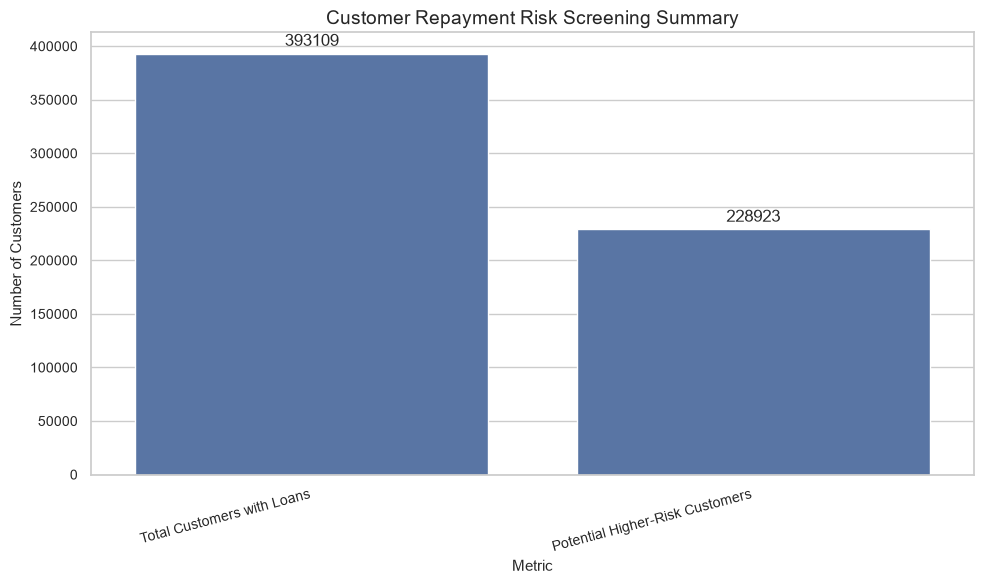

In [41]:
risk_count = risk_summary[
    risk_summary["Metric"].isin([
        "Total Customers with Loans",
        "Potential Higher-Risk Customers"
    ])
].copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=risk_count,
    x="Metric",
    y="Value"
)

plt.title("Customer Repayment Risk Screening Summary")
plt.xlabel("Metric")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15, ha="right")

for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

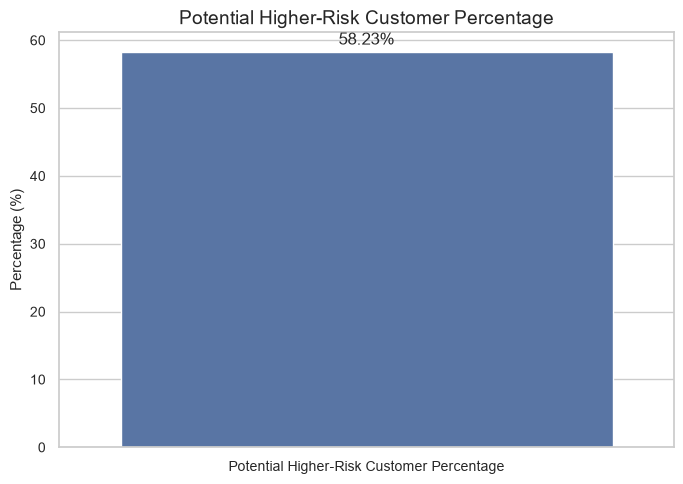

In [42]:
risk_percentage = risk_summary[
    risk_summary["Metric"]
    == "Potential Higher-Risk Customer Percentage"
]

plt.figure(figsize=(7, 5))

sns.barplot(
    data=risk_percentage,
    x="Metric",
    y="Value"
)

plt.title("Potential Higher-Risk Customer Percentage")
plt.xlabel("")
plt.ylabel("Percentage (%)")

for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Business Answer

Customers who may represent higher repayment risk are identified using
repayment ratios and loan status information.

The analysis identifies 228,923 potential higher-risk customers,
representing 58.23% of the 393,109 customers with loans. Customers
with low repayment ratios or loan statuses indicating possible
repayment concerns are flagged for further review.

This information helps the bank identify customers who may require
additional monitoring and supports the assessment of repayment risk.

Note: These are potential risk indicators, not confirmed defaults.
Rejected loans are also included in the results, so the flagged
customers should be reviewed before drawing conclusions about
actual repayment risk.

## Business Question 24: How have deposits changed month by month?

### Objective
The objective of this analysis is to examine monthly deposit trends
and understand how the bank's total deposits have changed over time.

### Key Metrics
- Monthly total deposits
- Month-over-month deposit change
- Month-over-month deposit growth rate

### Expected Outcome
Identify monthly deposit trends, including increases and decreases,
to understand changes in the bank's deposit activity over time.

In [43]:
# Convert OpenDate to datetime format

accounts["OpenDate"] = pd.to_datetime(
    accounts["OpenDate"],
    errors="coerce"
)

# Extract year and month

accounts["DepositMonth"] = (
    accounts["OpenDate"].dt.to_period("M")
)

accounts[["AccountID", "OpenDate", "Balance", "DepositMonth"]].head()

,AccountID,OpenDate,Balance,DepositMonth
0,1000001,2021-02-28,59731.28,2021-02
1,1000002,2023-04-06,164506.93,2023-04
2,1000003,2019-02-06,192647.75,2019-02
3,1000004,2021-05-04,133528.07,2021-05
4,1000005,2026-06-23,108520.97,2026-06


In [44]:
# Calculate total deposits for each month

monthly_deposits = (
    accounts.groupby("DepositMonth")
    .agg(
        TotalDeposits=("Balance", "sum"),
        TotalAccounts=("AccountID", "nunique")
    )
    .reset_index()
)

monthly_deposits["DepositMonth"] = (
    monthly_deposits["DepositMonth"].astype(str)
)

monthly_deposits

,DepositMonth,TotalDeposits,TotalAccounts
0,2018-01,1.574177e+09,12981
1,2018-02,1.430809e+09,11681
2,2018-03,1.606205e+09,12881
3,2018-04,1.497004e+09,12320
4,2018-05,1.594966e+09,12858
...,...,...,...
97,2026-02,1.429309e+09,11521
98,2026-03,1.612746e+09,12980
99,2026-04,1.541983e+09,12409
100,2026-05,1.624958e+09,12964


In [45]:
# Calculate monthly deposit changes

monthly_deposits["PreviousMonthDeposits"] = (
    monthly_deposits["TotalDeposits"].shift(1)
)

monthly_deposits["DepositChange"] = (
    monthly_deposits["TotalDeposits"]
    - monthly_deposits["PreviousMonthDeposits"]
)

monthly_deposits["DepositGrowthRate"] = (
    monthly_deposits["DepositChange"]
    / monthly_deposits["PreviousMonthDeposits"]
) * 100

monthly_deposits

,DepositMonth,TotalDeposits,TotalAccounts,PreviousMonthDeposits,DepositChange,DepositGrowthRate
0,2018-01,1.574177e+09,12981,NaN,NaN,NaN
1,2018-02,1.430809e+09,11681,1.574177e+09,-1.433677e+08,-9.107469
2,2018-03,1.606205e+09,12881,1.430809e+09,1.753958e+08,12.258503
3,2018-04,1.497004e+09,12320,1.606205e+09,-1.092009e+08,-6.798686
4,2018-05,1.594966e+09,12858,1.497004e+09,9.796179e+07,6.543855
...,...,...,...,...,...,...
97,2026-02,1.429309e+09,11521,1.568130e+09,-1.388209e+08,-8.852639
98,2026-03,1.612746e+09,12980,1.429309e+09,1.834370e+08,12.833960
99,2026-04,1.541983e+09,12409,1.612746e+09,-7.076319e+07,-4.387745
100,2026-05,1.624958e+09,12964,1.541983e+09,8.297489e+07,5.381051


In [46]:
# Identify months with the highest and lowest deposits

highest_deposit_month = monthly_deposits.loc[
    monthly_deposits["TotalDeposits"].idxmax()
]

lowest_deposit_month = monthly_deposits.loc[
    monthly_deposits["TotalDeposits"].idxmin()
]

print("Highest Deposit Month:", highest_deposit_month["DepositMonth"])
print(
    "Highest Total Deposits:",
    round(highest_deposit_month["TotalDeposits"], 2)
)

print("Lowest Deposit Month:", lowest_deposit_month["DepositMonth"])
print(
    "Lowest Total Deposits:",
    round(lowest_deposit_month["TotalDeposits"], 2)
)

Highest Deposit Month: 2021-05
Highest Total Deposits: 1648893876.45
Lowest Deposit Month: 2023-02
Lowest Total Deposits: 1389783880.24


## BQ24: Monthly Deposit Trend

This visualization displays account balances grouped by
account opening month, using the existing monthly_deposits
DataFrame.

Important limitation:
The current analysis groups account balances by OpenDate.
It does not measure actual monthly deposit transactions.
Therefore, the chart represents account balances by
account opening month, not monthly deposit inflows.

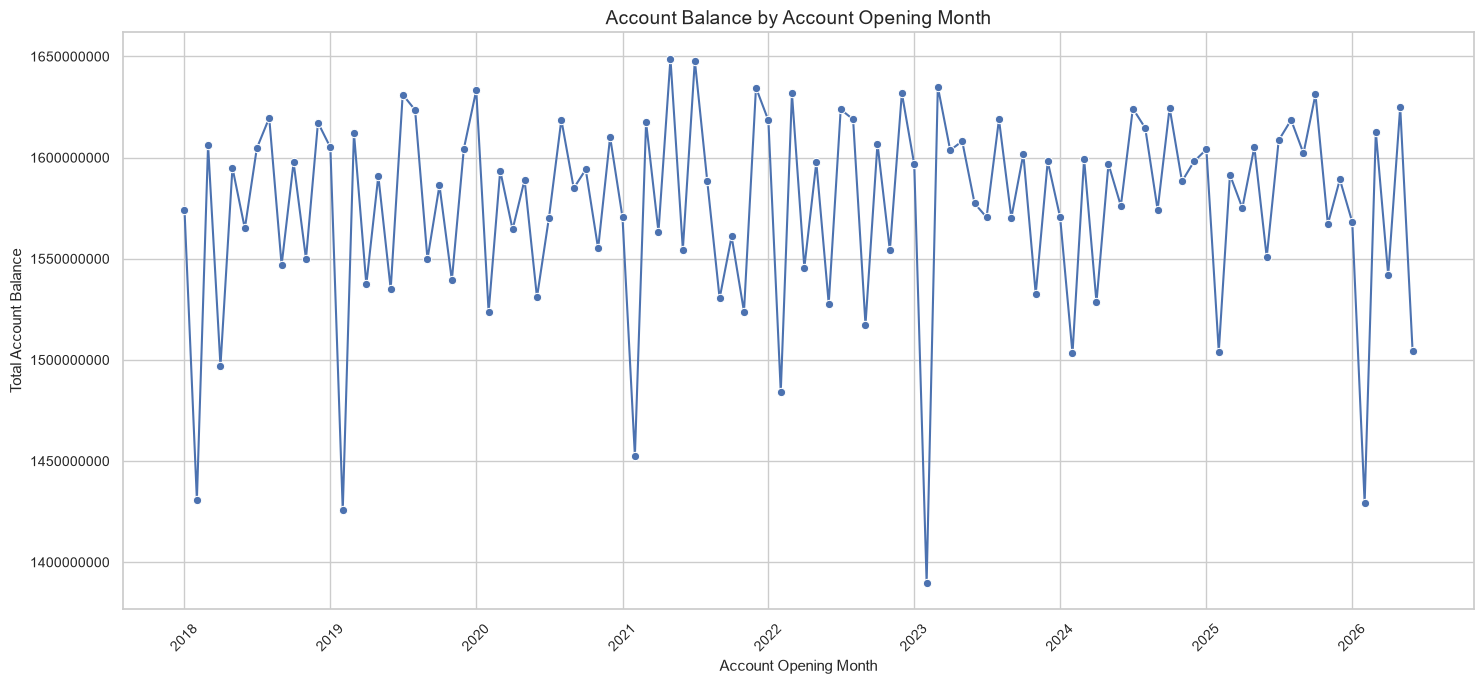

In [47]:
monthly_deposit_plot = monthly_deposits.copy()

monthly_deposit_plot["DepositMonth"] = pd.to_datetime(
    monthly_deposit_plot["DepositMonth"],
    errors="coerce"
)

monthly_deposit_plot = monthly_deposit_plot.dropna(
    subset=["DepositMonth"]
).sort_values("DepositMonth")

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=monthly_deposit_plot,
    x="DepositMonth",
    y="TotalDeposits",
    marker="o"
)

plt.title("Account Balance by Account Opening Month")
plt.xlabel("Account Opening Month")
plt.ylabel("Total Account Balance")

plt.xticks(rotation=45)
plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.tight_layout()
plt.show()

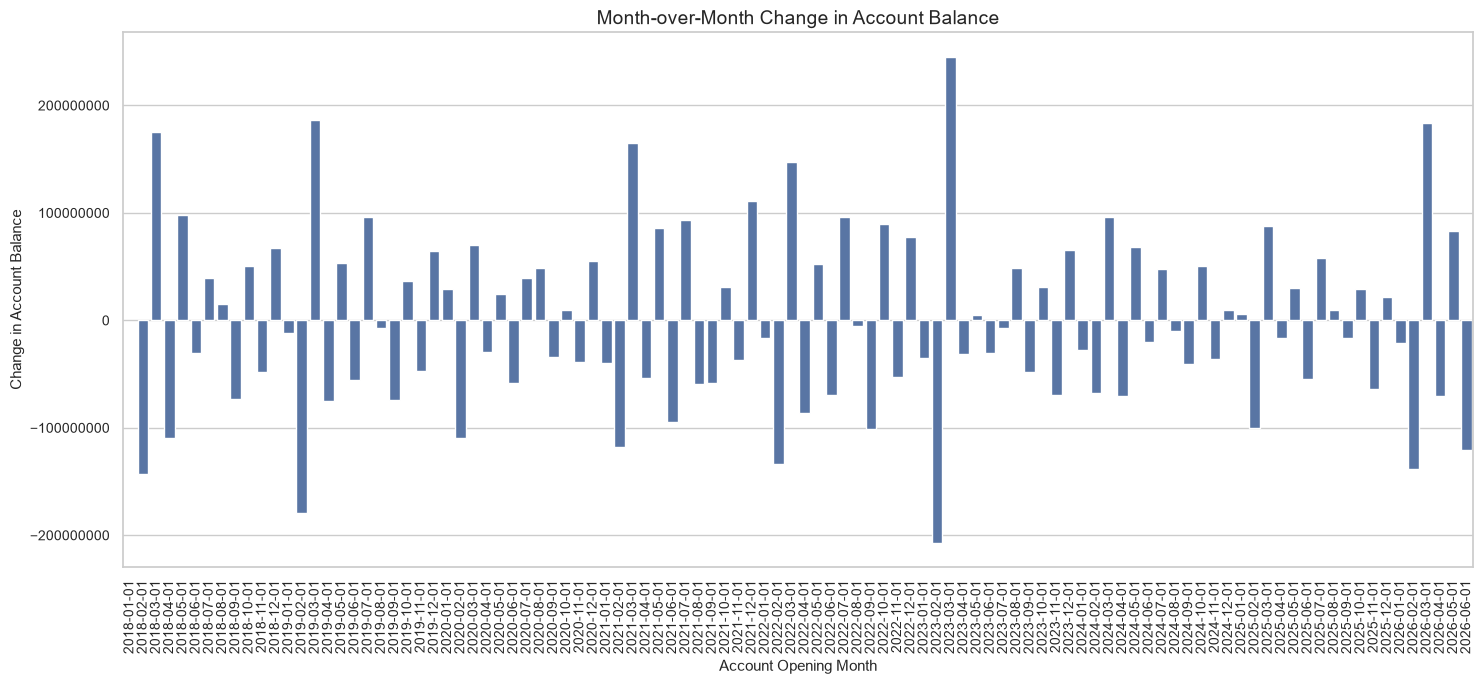

In [48]:
plt.figure(figsize=(15, 7))

sns.barplot(
    data=monthly_deposit_plot,
    x="DepositMonth",
    y="DepositChange"
)

plt.title("Month-over-Month Change in Account Balance")
plt.xlabel("Account Opening Month")
plt.ylabel("Change in Account Balance")

plt.xticks(rotation=90)
plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.tight_layout()
plt.show()

### Business Answer

Monthly deposit analysis helps identify how the bank's total deposits
have changed over time.

The analysis shows that deposits associated with accounts opened
fluctuated from month to month. The highest total deposits were
recorded in May 2021, at approximately 1.65 billion, while the
lowest were recorded in February 2023, at approximately 1.39 billion.

This information helps the bank understand deposit trends, monitor
changes in deposit activity, and support financial planning.

Note: Deposits are calculated using account balances grouped by
account opening month. This represents deposits associated with
accounts opened in each month, not actual monthly deposit transactions.

## Business Question 25: How have loans changed month by month?

Analyze the monthly trend of loans to understand how the bank's loan portfolio has changed over time.

The analysis should include:
- Total loan amount by month
- Number of loans by month
- Month-over-month change in loan amount
- Month-over-month growth rate
- Highest and lowest loan months

In [49]:
# Convert LoanDate to datetime
loans["LoanDate"] = pd.to_datetime(loans["LoanDate"])

# Create monthly loan trend
monthly_loans = (
    loans
    .groupby(loans["LoanDate"].dt.to_period("M"))
    .agg(
        TotalLoans=("LoanID", "count"),
        TotalLoanAmount=("LoanAmount", "sum")
    )
    .reset_index()
)

# Convert period to string
monthly_loans["LoanDate"] = monthly_loans["LoanDate"].astype(str)

monthly_loans.head()

,LoanDate,TotalLoans,TotalLoanAmount
0,2019-01,5465,5.881875e+09
1,2019-02,5194,5.425323e+09
2,2019-03,5618,5.873324e+09
3,2019-04,5361,5.672732e+09
4,2019-05,5730,6.123911e+09


In [50]:
# Calculate month-over-month change
monthly_loans["MoM_Loan_Change"] = (
    monthly_loans["TotalLoanAmount"].diff()
)

# Calculate month-over-month growth rate
monthly_loans["MoM_Growth_Rate"] = (
    monthly_loans["TotalLoanAmount"].pct_change() * 100
)

monthly_loans.head(10)

,LoanDate,TotalLoans,TotalLoanAmount,MoM_Loan_Change,MoM_Growth_Rate
0,2019-01,5465,5.881875e+09,NaN,NaN
1,2019-02,5194,5.425323e+09,-4.565522e+08,-7.762019
2,2019-03,5618,5.873324e+09,4.480017e+08,8.257604
3,2019-04,5361,5.672732e+09,-2.005927e+08,-3.415318
4,2019-05,5730,6.123911e+09,4.511789e+08,7.953467
5,2019-06,5388,5.661402e+09,-4.625091e+08,-7.552512
6,2019-07,5716,5.944559e+09,2.831579e+08,5.001552
7,2019-08,5514,5.732010e+09,-2.125495e+08,-3.575531
8,2019-09,5366,5.659887e+09,-7.212314e+07,-1.258252
9,2019-10,5581,5.852163e+09,1.922759e+08,3.397169


In [51]:
# Highest loan amount month
highest_loan_month = monthly_loans.loc[
    monthly_loans["TotalLoanAmount"].idxmax()
]

# Lowest loan amount month
lowest_loan_month = monthly_loans.loc[
    monthly_loans["TotalLoanAmount"].idxmin()
]

print("Highest Loan Month:")
print(highest_loan_month)

print("\nLowest Loan Month:")
print(lowest_loan_month)

Highest Loan Month:
LoanDate                 2024-05
TotalLoans                  5859
TotalLoanAmount    6239936032.51
MoM_Loan_Change     302607085.14
MoM_Growth_Rate         5.096687
Name: 64, dtype: object

Lowest Loan Month:
LoanDate                 2021-02
TotalLoans                  5123
TotalLoanAmount    5294258110.96
MoM_Loan_Change    -642371556.58
MoM_Growth_Rate       -10.820475
Name: 25, dtype: object


In [52]:
monthly_loans

,LoanDate,TotalLoans,TotalLoanAmount,MoM_Loan_Change,MoM_Growth_Rate
0,2019-01,5465,5.881875e+09,NaN,NaN
1,2019-02,5194,5.425323e+09,-4.565522e+08,-7.762019
2,2019-03,5618,5.873324e+09,4.480017e+08,8.257604
3,2019-04,5361,5.672732e+09,-2.005927e+08,-3.415318
4,2019-05,5730,6.123911e+09,4.511789e+08,7.953467
...,...,...,...,...,...
85,2026-02,5114,5.401838e+09,-6.074327e+08,-10.108260
86,2026-03,5613,5.745830e+09,3.439920e+08,6.368055
87,2026-04,5490,5.781656e+09,3.582657e+07,0.623523
88,2026-05,5677,6.018156e+09,2.364993e+08,4.090512


## BQ25: Monthly Loan Trend

This visualization presents the monthly trend in total
loan amounts and the number of loans.

It helps identify changes in loan activity over time.

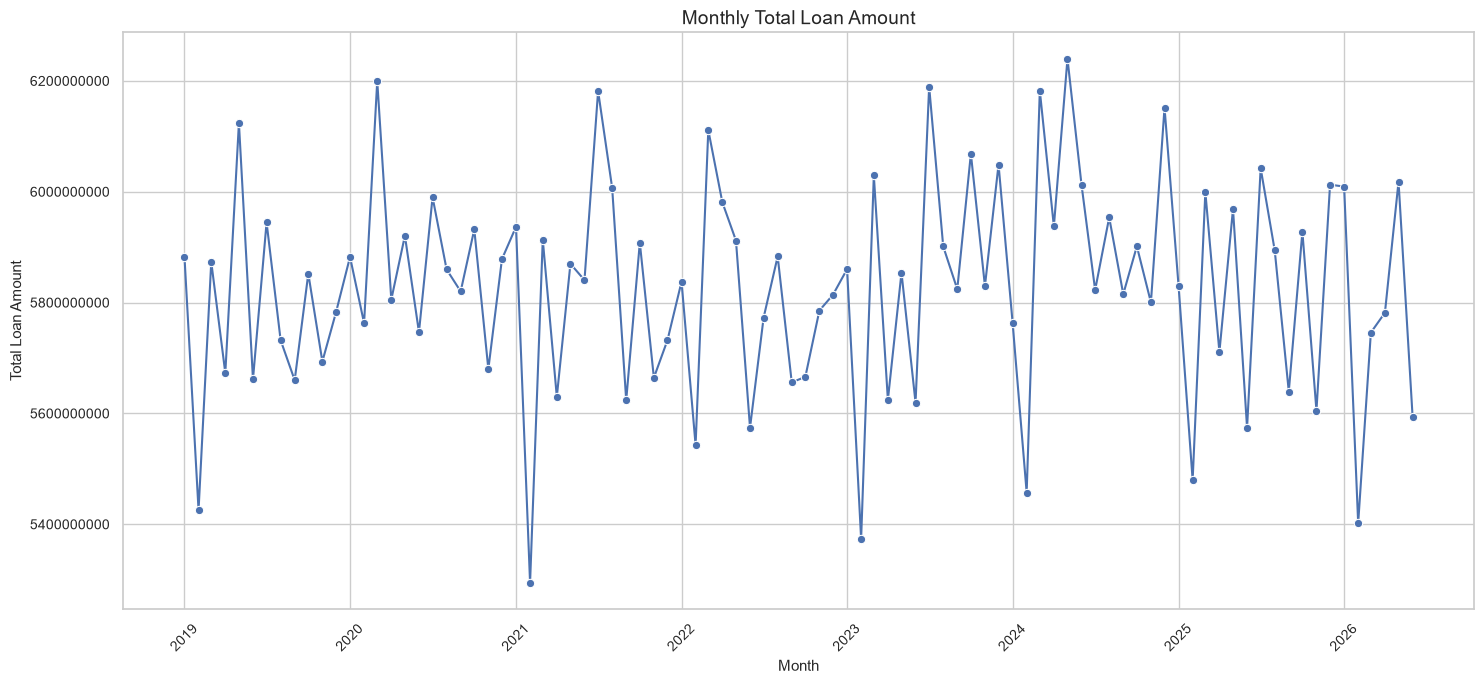

In [53]:
monthly_loan_plot = monthly_loans.copy()

monthly_loan_plot["LoanDate"] = pd.to_datetime(
    monthly_loan_plot["LoanDate"],
    errors="coerce"
)

monthly_loan_plot = monthly_loan_plot.dropna(
    subset=["LoanDate"]
).sort_values("LoanDate")

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=monthly_loan_plot,
    x="LoanDate",
    y="TotalLoanAmount",
    marker="o"
)

plt.title("Monthly Total Loan Amount")
plt.xlabel("Month")
plt.ylabel("Total Loan Amount")

plt.xticks(rotation=45)
plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.tight_layout()
plt.show()

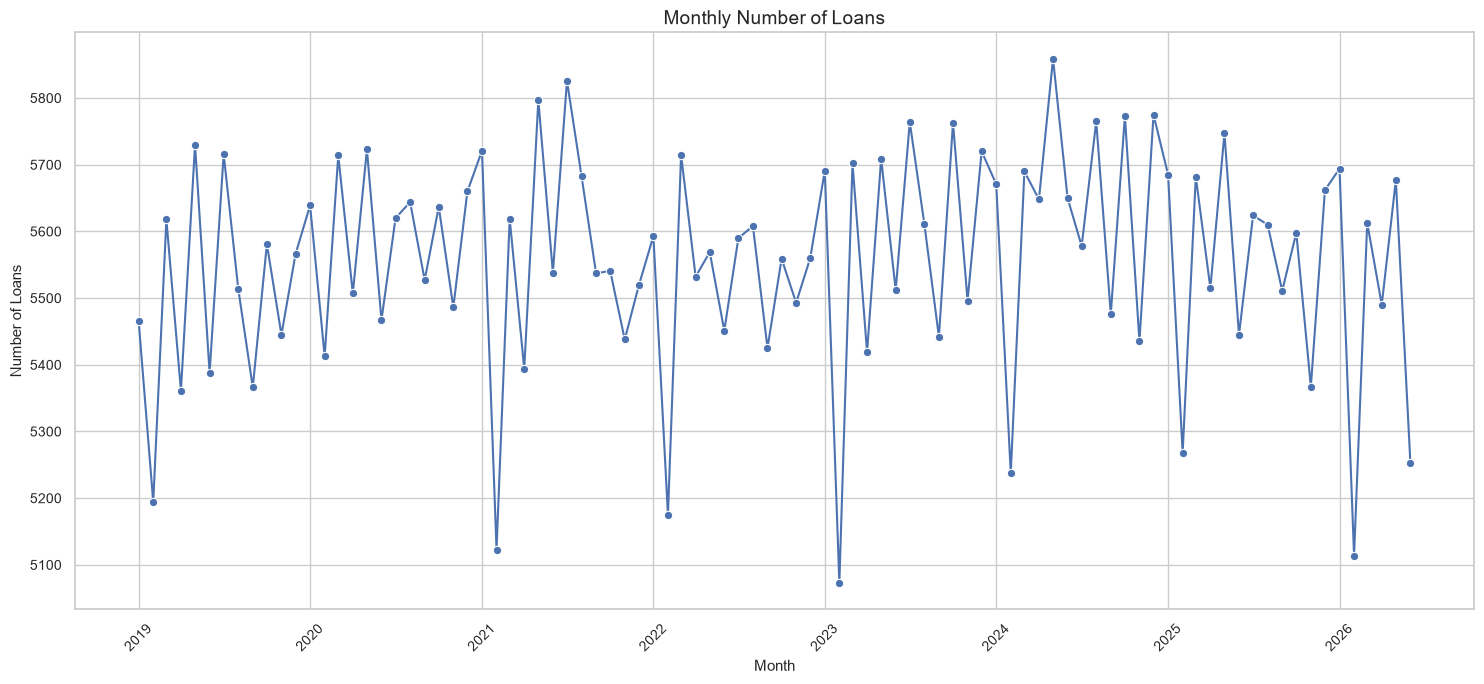

In [54]:
plt.figure(figsize=(15, 7))

sns.lineplot(
    data=monthly_loan_plot,
    x="LoanDate",
    y="TotalLoans",
    marker="o"
)

plt.title("Monthly Number of Loans")
plt.xlabel("Month")
plt.ylabel("Number of Loans")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Business Answer

The monthly loan analysis shows that the bank's lending activity fluctuated between January 2019 and June 2026.

May 2024 recorded the highest total loan amount, approximately 6.24 billion, across 5,859 loans. In contrast, February 2021 recorded the lowest total loan amount, approximately 5.29 billion, across 5,123 loans.

The month-over-month analysis shows that loan amounts increased in some months and decreased in others. For example, loan amounts increased by approximately 5.10% in May 2024 compared with the previous month.

These fluctuations help the bank monitor changes in lending activity, understand borrowing patterns, and plan its lending operations. Management can use this information to investigate significant monthly changes and support future loan portfolio planning.

## Business Question 26: Which transaction channel is most popular?

Analyze transaction records to identify the most frequently used transaction channel.

The analysis will:
- Calculate the total number of transactions for each channel.
- Calculate each channel's percentage of total transactions.
- Identify the most popular transaction channel.
- Compare transaction activity across channels.

In [55]:
# Count transactions for each channel
channel_counts = (
    transactions
    .groupby("Channel")
    .agg(
        TotalTransactions=("TransactionID", "count")
    )
    .reset_index()
)

# Sort by transaction count
channel_counts = channel_counts.sort_values(
    by="TotalTransactions",
    ascending=False
).reset_index(drop=True)

channel_counts

,Channel,TotalTransactions
0,Mobile,1249106
1,Internet Banking,900653
2,ATM,898735
3,POS,749870
4,QR,601414
5,Branch,600222


In [56]:
# Calculate percentage of total transactions
total_transactions = transactions["TransactionID"].count()

channel_counts["TransactionPercentage"] = (
    channel_counts["TotalTransactions"]
    / total_transactions
    * 100
)

channel_counts

,Channel,TotalTransactions,TransactionPercentage
0,Mobile,1249106,24.98212
1,Internet Banking,900653,18.01306
2,ATM,898735,17.97470
3,POS,749870,14.99740
4,QR,601414,12.02828
5,Branch,600222,12.00444


In [57]:
# Identify the channel with the highest transaction count
most_popular_channel = channel_counts.iloc[0]

print("Most Popular Transaction Channel:")
print("Channel:", most_popular_channel["Channel"])
print("Total Transactions:", most_popular_channel["TotalTransactions"])
print(
    "Transaction Percentage:",
    round(most_popular_channel["TransactionPercentage"], 2),
    "%"
)

Most Popular Transaction Channel:
Channel: Mobile
Total Transactions: 1249106
Transaction Percentage: 24.98 %


In [58]:
# Display channel comparison
channel_comparison = channel_counts[
    ["Channel", "TotalTransactions", "TransactionPercentage"]
].copy()

channel_comparison


,Channel,TotalTransactions,TransactionPercentage
0,Mobile,1249106,24.98212
1,Internet Banking,900653,18.01306
2,ATM,898735,17.97470
3,POS,749870,14.99740
4,QR,601414,12.02828
5,Branch,600222,12.00444


## BQ26: Transaction Channel Popularity

This visualization compares transaction volumes across
different transaction channels.

The percentage labels represent each channel's share
of total transactions.

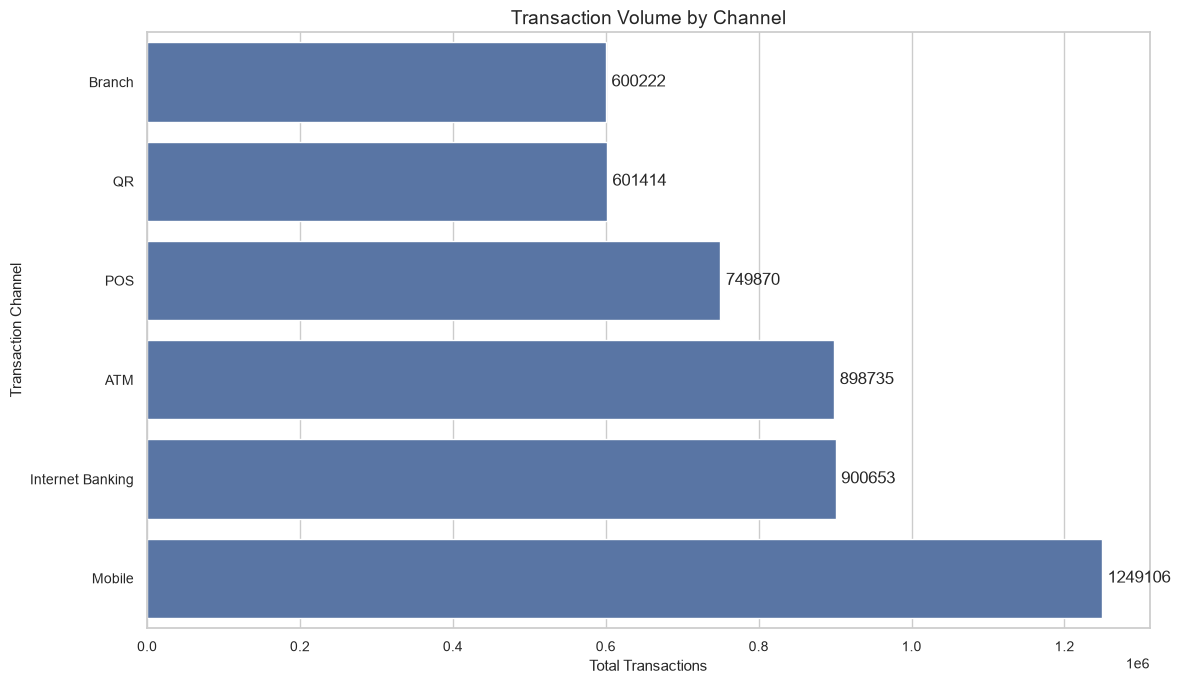

In [59]:
channel_plot = channel_counts.sort_values(
    "TotalTransactions",
    ascending=True
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=channel_plot,
    x="TotalTransactions",
    y="Channel"
)

plt.title("Transaction Volume by Channel")
plt.xlabel("Total Transactions")
plt.ylabel("Transaction Channel")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4
    )

plt.tight_layout()
plt.show()

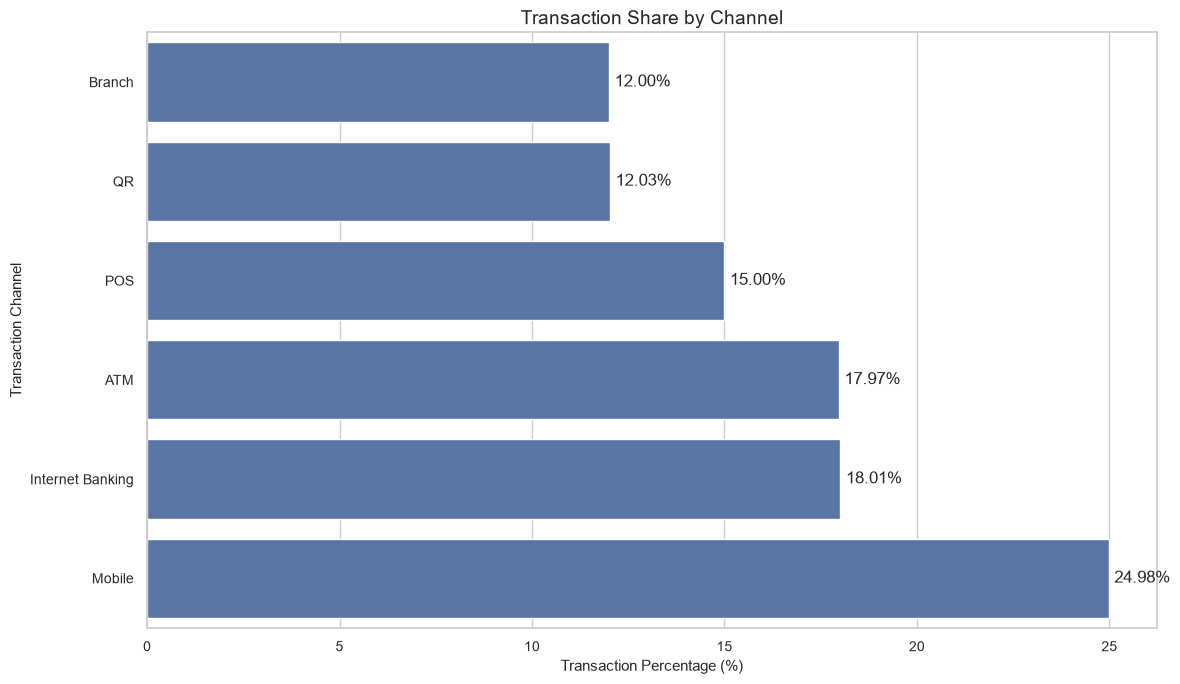

In [60]:
channel_percentage_plot = channel_counts.sort_values(
    "TransactionPercentage",
    ascending=True
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=channel_percentage_plot,
    x="TransactionPercentage",
    y="Channel"
)

plt.title("Transaction Share by Channel")
plt.xlabel("Transaction Percentage (%)")
plt.ylabel("Transaction Channel")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4
    )

plt.tight_layout()
plt.show()

## Business Answer

The analysis identifies **Mobile** as the most popular transaction channel, with **1,249,106 transactions**, representing **24.98%** of all transactions.

Internet Banking ranks second with 900,653 transactions (18.01%), closely followed by ATM with 898,735 transactions (17.97%). POS accounts for 14.997%, QR for 12.03%, and Branch for 12.00% of total transactions.

The results show that Mobile is the most frequently used channel in the dataset. The bank can use these findings to understand customer channel preferences, manage transaction services, and plan operational resources based on channel usage.

## Business Question 27: Which customer segments should the bank target for new products?

Analyze customer segments based on income, deposits, and loan activity to identify potential opportunities for new banking products.

The analysis will:
- Segment customers by income.
- Compare customer counts across segments.
- Analyze deposits and loan amounts by segment.
- Identify segments that may represent opportunities for new products.
- Provide data-driven recommendations for product development.

In [61]:
# Create a copy of the customer dataset
customer_segments = customers.copy()

# Define income categories
income_bins = [0, 25000, 50000, 100000, float("inf")]

income_labels = [
    "Low Income",
    "Lower-Middle Income",
    "Upper-Middle Income",
    "High Income"
]

# Create customer segments
customer_segments["IncomeSegment"] = pd.cut(
    customer_segments["Income"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

# Display customer segment counts
customer_segments["IncomeSegment"].value_counts()

IncomeSegment
Lower-Middle Income    433741
Upper-Middle Income    351749
Low Income             142606
High Income             72904
Name: count, dtype: int64

In [62]:
# Calculate customer metrics by income segment
segment_analysis = (
    customer_segments
    .groupby("IncomeSegment", observed=False)
    .agg(
        TotalCustomers=("CustomerID", "nunique"),
        AverageIncome=("Income", "mean")
    )
    .reset_index()
)

# Calculate customer percentage
total_customers = customer_segments["CustomerID"].nunique()

segment_analysis["CustomerPercentage"] = (
    segment_analysis["TotalCustomers"]
    / total_customers
    * 100
)

segment_analysis

,IncomeSegment,TotalCustomers,AverageIncome,CustomerPercentage
0,Low Income,142322,19472.810064,14.2322
1,Lower-Middle Income,432872,37132.669845,43.2872
2,Upper-Middle Income,351071,68096.922366,35.1071
3,High Income,72735,131098.568741,7.2735


In [63]:
# Merge accounts with customer segments
account_segment_data = accounts.merge(
    customer_segments[["CustomerID", "IncomeSegment"]],
    on="CustomerID",
    how="left"
)

# Calculate deposit metrics by segment
segment_deposits = (
    account_segment_data
    .groupby("IncomeSegment", observed=False)
    .agg(
        TotalDeposits=("Balance", "sum"),
        AverageAccountBalance=("Balance", "mean"),
        TotalAccounts=("AccountID", "nunique")
    )
    .reset_index()
)

segment_deposits

,IncomeSegment,TotalDeposits,AverageAccountBalance,TotalAccounts
0,Low Income,2.285766e+10,123526.868720,184666
1,Lower-Middle Income,6.965379e+10,123583.993378,562491
2,Upper-Middle Income,5.663935e+10,123769.118519,456727
3,High Income,1.169689e+10,122993.119726,94873


In [64]:
# Merge loans with customer segments
loan_segment_data = loans.merge(
    customer_segments[["CustomerID", "IncomeSegment"]],
    on="CustomerID",
    how="left"
)

# Calculate loan metrics by segment
segment_loans = (
    loan_segment_data
    .groupby("IncomeSegment", observed=False)
    .agg(
        TotalLoans=("LoanID", "nunique"),
        TotalLoanAmount=("LoanAmount", "sum"),
        AverageLoanAmount=("LoanAmount", "mean")
    )
    .reset_index()
)

segment_loans

,IncomeSegment,TotalLoans,TotalLoanAmount,AverageLoanAmount
0,Low Income,70795,7.398551e+10,1.042872e+06
1,Lower-Middle Income,217054,2.282322e+11,1.049344e+06
2,Upper-Middle Income,175212,1.843880e+11,1.050512e+06
3,High Income,36472,3.837592e+10,1.049756e+06


In [65]:
# Combine customer, deposit, and loan metrics
segment_summary = (
    segment_analysis
    .merge(
        segment_deposits,
        on="IncomeSegment",
        how="left"
    )
    .merge(
        segment_loans,
        on="IncomeSegment",
        how="left"
    )
)

# Calculate deposit and loan shares
total_deposits = segment_summary["TotalDeposits"].sum()
total_loan_amount = segment_summary["TotalLoanAmount"].sum()

segment_summary["DepositShare"] = (
    segment_summary["TotalDeposits"]
    / total_deposits
    * 100
)

segment_summary["LoanShare"] = (
    segment_summary["TotalLoanAmount"]
    / total_loan_amount
    * 100
)

# Display final segment analysis
segment_summary.round(2)

,IncomeSegment,TotalCustomers,AverageIncome,CustomerPercentage,TotalDeposits,AverageAccountBalance,TotalAccounts,TotalLoans,TotalLoanAmount,AverageLoanAmount,DepositShare,LoanShare
0,Low Income,142322,19472.81,14.23,2.285766e+10,123526.87,184666,70795,7.398551e+10,1042872.02,14.21,14.09
1,Lower-Middle Income,432872,37132.67,43.29,6.965379e+10,123583.99,562491,217054,2.282322e+11,1049343.60,43.30,43.47
2,Upper-Middle Income,351071,68096.92,35.11,5.663935e+10,123769.12,456727,175212,1.843880e+11,1050512.35,35.21,35.12
3,High Income,72735,131098.57,7.27,1.169689e+10,122993.12,94873,36472,3.837592e+10,1049755.71,7.27,7.31


In [66]:
# Sort segments by customer count
target_segment_analysis = segment_summary.sort_values(
    by="TotalCustomers",
    ascending=False
).reset_index(drop=True)

target_segment_analysis[
    [
        "IncomeSegment",
        "TotalCustomers",
        "CustomerPercentage",
        "AverageIncome",
        "TotalDeposits",
        "AverageAccountBalance",
        "TotalLoans",
        "TotalLoanAmount",
        "AverageLoanAmount"
    ]
].round(2)

,IncomeSegment,TotalCustomers,CustomerPercentage,AverageIncome,TotalDeposits,AverageAccountBalance,TotalLoans,TotalLoanAmount,AverageLoanAmount
0,Lower-Middle Income,432872,43.29,37132.67,6.965379e+10,123583.99,217054,2.282322e+11,1049343.60
1,Upper-Middle Income,351071,35.11,68096.92,5.663935e+10,123769.12,175212,1.843880e+11,1050512.35
2,Low Income,142322,14.23,19472.81,2.285766e+10,123526.87,70795,7.398551e+10,1042872.02
3,High Income,72735,7.27,131098.57,1.169689e+10,122993.12,36472,3.837592e+10,1049755.71


## BQ27: Customer Segment Analysis for Product Planning

These visualizations compare customer segments by
customer count, total deposits, and total loan amount.

The results describe the bank's existing customer
portfolio and can support further product research.

The charts do not establish which segment will respond
best to a new product. Product targeting requires
additional research into customer needs, eligibility,
profitability, and product demand.

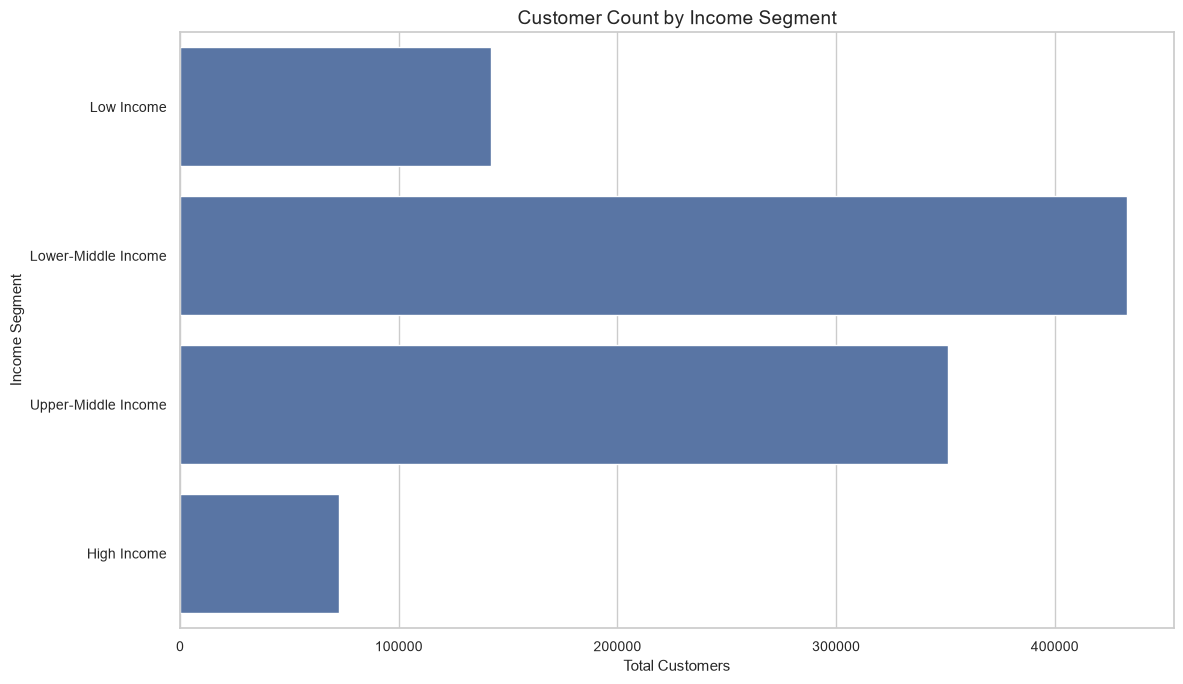

In [67]:
segment_customer_plot = target_segment_analysis.sort_values(
    "TotalCustomers",
    ascending=True
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=segment_customer_plot,
    x="TotalCustomers",
    y="IncomeSegment"
)

plt.title("Customer Count by Income Segment")
plt.xlabel("Total Customers")
plt.ylabel("Income Segment")

plt.tight_layout()
plt.show()

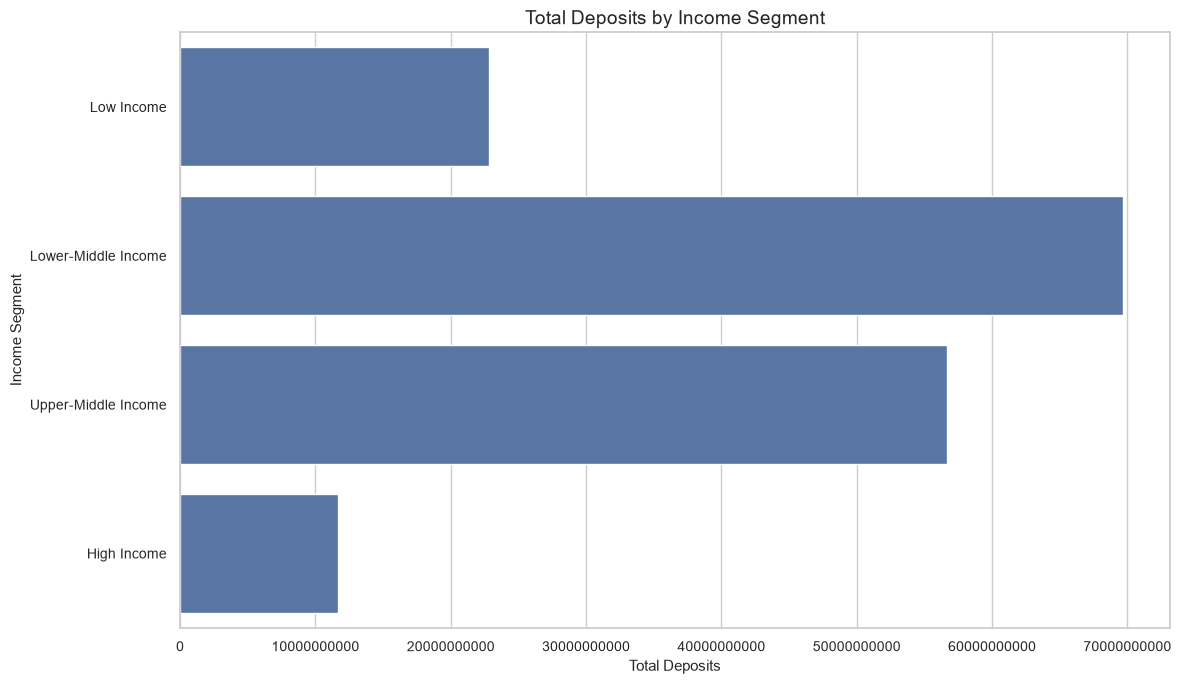

In [68]:
segment_deposit_plot = target_segment_analysis.sort_values(
    "TotalDeposits",
    ascending=True
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=segment_deposit_plot,
    x="TotalDeposits",
    y="IncomeSegment"
)

plt.title("Total Deposits by Income Segment")
plt.xlabel("Total Deposits")
plt.ylabel("Income Segment")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

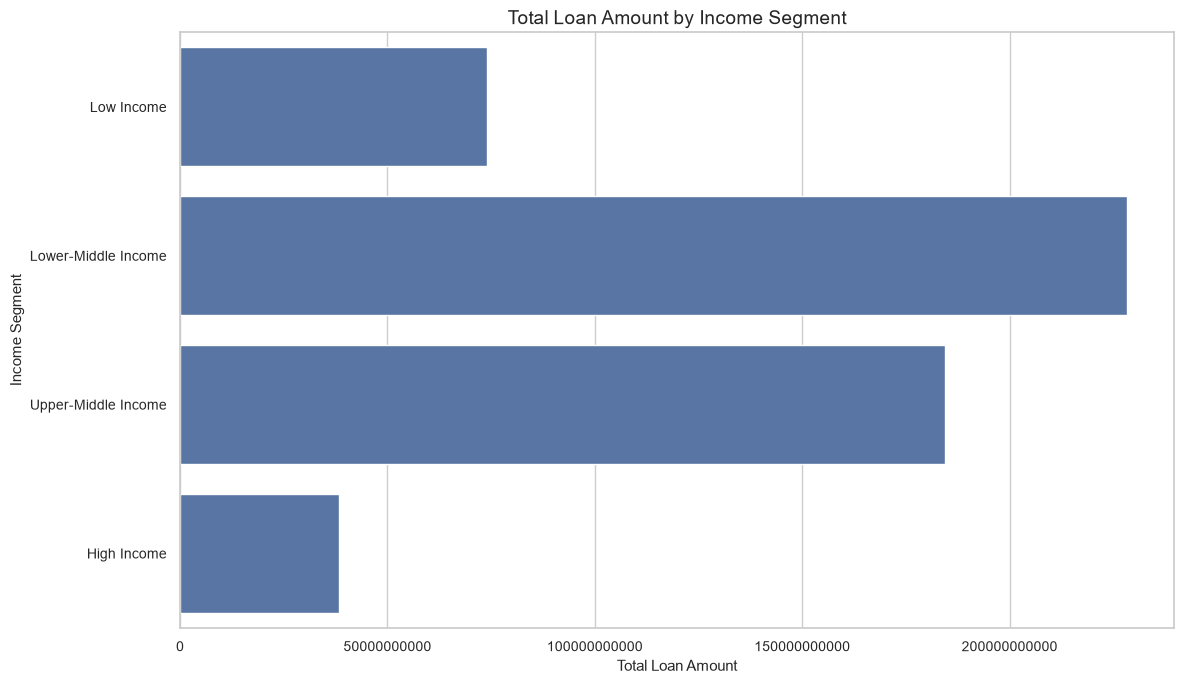

In [69]:
segment_loan_plot = target_segment_analysis.sort_values(
    "TotalLoanAmount",
    ascending=True
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=segment_loan_plot,
    x="TotalLoanAmount",
    y="IncomeSegment"
)

plt.title("Total Loan Amount by Income Segment")
plt.xlabel("Total Loan Amount")
plt.ylabel("Income Segment")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

## Business Answer

The analysis identifies **Lower-Middle Income** and **Upper-Middle Income** customers as significant segments for evaluating new banking products.

The Lower-Middle Income segment has the largest customer base, with 432,872 customers (43.29%). It contributes approximately 69.65 billion in deposits (43.30%) and 228.23 billion in loans (43.47%). This segment may offer opportunities for affordable savings accounts, personal loans, and other products designed for a broad customer base.

The Upper-Middle Income segment includes 351,071 customers (35.11%), contributing approximately 56.64 billion in deposits and 184.39 billion in loans. Its average loan amount is approximately 1.05 million. The bank could evaluate this segment for premium savings accounts, investment services, and tailored loan products.

The Low Income segment represents 14.23% of customers and may be considered for affordable savings products and accessible financial services. The High Income segment represents 7.27% of customers and may be considered for premium banking services.

Based on customer numbers and current portfolio contributions, the bank can evaluate product opportunities across all four segments. However, these findings show existing banking activity, not confirmed demand. Customer surveys and product preference research would help validate which products each segment wants.